## Heston Model and Model Calibration

#### Manan Verma

#### 16 August, 2026

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import yfinance as yf 
import pandas as pd 
from scipy.integrate import quad
from scipy.stats import norm
import random

***  
#### Heston Modeling

The ***Heston Model*** aims to improve upon the *Black Scholes* model by introducing the idea that **volatility is not constant**.

For a stock, commodity, or other security, **volatility** is the speed and amount that its prices fluctuate over time. Mathematically, volatility is the standard deviation of the returns of the fund over a set period of time across equally sized time periods.

The Heston model, similar to the Black Scholes Model, assumes that stock prices follow *Geometric Brownian Motion*:
$$dS_t = \mu S_t dt + \sqrt{v_t}S_t dW^S_t$$
However, notice here that, rather than being a constant ($\sigma$), volatility is itself a function ($\sqrt{v_t}$). Specifically, the Heston Model assumes that volatility follows a *mean-reverting, square-root-diffusion* process.

A mean-reverting process describes a model in which the underlying variable fluctuates but continuously gets pulled towards and drifts to a long term average. The further the variable is from the mean, the stronger the "attraction" is towards the mean. The most commonly used continuous-time mean-reverting process is known as the *Ornstein-Uhlenbeck* Process:
$$dX_t = \theta (\mu - X_t)dt + \sigma dW_t$$
where $X_t$ is the value of the variable at time $t$,  
$\theta$ is the rate at which the variable reverts back to the mean,  
$\mu$ is the long-term mean,  
$\sigma$ is the volatility of the underlying variable,  
and $W_t$ is a standard Weiner Process.
Take note of the drift term: $\theta (\mu - X_t)dt$. If $X_t$ is larger than $\mu$, then the drift is negative, pushing the variable downwards, and vice versa. Alse, the further $X_t$ is from $\mu$, the larger the "pull" is on the variable.

A square-root-diffusion process is a model defined by a stochatic differential equation which includes a $\sqrt{X_t}$ term:
$$dX_t = \theta (\mu - X_t)dt + \sigma \sqrt{X_t}dW_t$$
This new term helps prevent negaive values because, as $X_t$ approaches 0, the $\sqrt{X_t}$ term also approaches 0, decreasing the effects of the $dW_t$ term as $X_t$ approaches 0. Note that a linear term ($X_t$) cannot be used in this situation because it would make it impossible for the underlying process to attain a value of 0, but during extreme financial conditions, the flexibility to allow volatility to attain 0 is actually wanted. Furthermore, as volatility increases to high values, a linear term would cause it to explode too fast. In addition to this, in order to ensure the process is strictly positive, it must satisfy the Feller condition: $2\theta\mu > \sigma^2$. A mean-reverting, square-root-diffusion is known as a **Cox-Ingross-Ross (CIR) process**.

With these two processes, the model for volatility can be derived:
$$dv_t = \kappa (\theta - v_t)dt + \xi\sqrt{v_t}dW^v_t$$
where $\kappa$ is mean-reverting rate of volatility,  
$\theta$ is the long-term mean of volatility,  
and $\xi$ is the volatility of the volatility (a.k.a., "vol of vol")  
Also, the two stochastic terms, $dW^S_t$ and $dW^v_t$ have correlation coefficient $\rho$ ($-1 < \rho < 1$), with: $\langle dW^S_t, dW^v_t \rangle = \rho dt$  

***

The volatility SDE does not have a closed-form pathwise solution like Geometric Brownian Motion does, rather it has a closed-form *transition density* that describes how the next step may evolve from the current time step. Furthermore, the complete derivation is substantially more involved than the derivation for Geometric Brownian Motion. Thus, only major stages in the derivation will be shown-  
Starting from the CIR process, first an *infinitesimal generator*, $\mathscr{A}$ is constructed, which is an operator that describes the average change of a function over an infinitesinally small time-step for continuous-time Markov processes (a Markov process describes a process where future states depend only on the current state but not on previous states, like the CIR process). Mathematically, for a Markov Process $W_t$, this is:
$$\mathscr{A}f(x) = \lim_{x \to 0^+} \frac{\mathbb{E}[f(W_t)] - f(x)}{t} $$
and for the CIR process, the generator acting on a function $f$ is:
$$\mathscr{A}f(x) = \frac{df}{dx}\kappa(\theta - x) + \frac{1}{2}\frac{d^2f}{dx^2}\sigma^2x$$
Then, the adjoint of the generator can be defined as $\mathscr{A}^*$, where the adjoint of an operator, $L$ satisfies: $\langle L(f), g\rangle = \langle f, L^*(g)\rangle$. With this, the *Kolmogorov Forward Equation* (Fokker-Planck Equation) can be derived and applied to the CIR SDE in order to obtain the PDE for the transition density, $p(v, t | v_0)$, which describes the evolution of the probability density rather than sample paths:
$$\frac{\partial p_{v, t}}{\partial t} = \mathscr{A}^*p_{v, t}$$
$$\Rightarrow \frac{\partial p_{v, t}}{\partial t} = -\frac{\partial}{\partial v}\left[\kappa(\theta - v)p_{v, t}\right] + \frac{1}{2}\frac{\partial^2}{\partial v^2}\left(\xi^2vp_{v, t}\right)$$
Next, the Laplace transform of $p$ will be taken to convert derivatives with respect to $v$ into algebraic expressions in terms of $s$, with $s \in \mathbb{C}$:
$$L(s, t) = \mathcal{L}\{p_{v, t}\} = \int_0^{\infty} e^{-sv}p_{v, t}dv$$
And, after solving the integral, a first-order PDE for the transform is found:
$$\frac{\partial L}{\partial t} = -\frac{\partial L}{\partial s}\kappa s - \frac{1}{2}\frac{\partial L}{\partial s}\xi^2s^2 - \kappa\theta sL$$
Solving for the Laplace Transform, a closed-form solution is found:
$$L(s, t) = \frac{\mathrm{exp}\left(-\frac{Cse^{-\kappa t}}{1 + sD}\right)}{(1 + sD)^{\nu}}$$
where $C$, $D$, and $\nu$ are functions of $\kappa, \theta, \xi, t, v_0$.  
Finally, comparing this Laplace Transform with a table of Laplace Transforms, it matches exactly with that of a **scaled, non-central Chi-squared** random variable. Specifically, it can be shown that $v_t$ is distributed as follows:
$$\frac{4\kappa}{\xi^2\left(1 - e^{-\kappa \Delta t}\right)}v_{t + \Delta t} \sim \chi^2\left(\frac{4\kappa \theta}{\xi^2}, ~ \frac{4\kappa e^{-\kappa \Delta t}}{\xi^2(1 - e^{-\kappa \Delta t})}v_t\right)$$
Where the first parameter of $\chi^2(\cdot)$ is the degrees of freedom, and the second parameter is the non-centrality parameter, $\lambda$.

*Also, recall that the closed form solution for Geometric Brownian Motion is given by:*
$$S_{t + \Delta t} = S_t\textrm{exp}\left[\left(\mu - \frac{1}{2}v_t\right)\Delta t + \sqrt{v_t} W_t\right]$$
$$with ~~ W_t = \sqrt{\Delta t}Z~~, Z \sim \mathcal{N}(0, 1)$$

Below, the dynamics of the CIR process will be modeled:

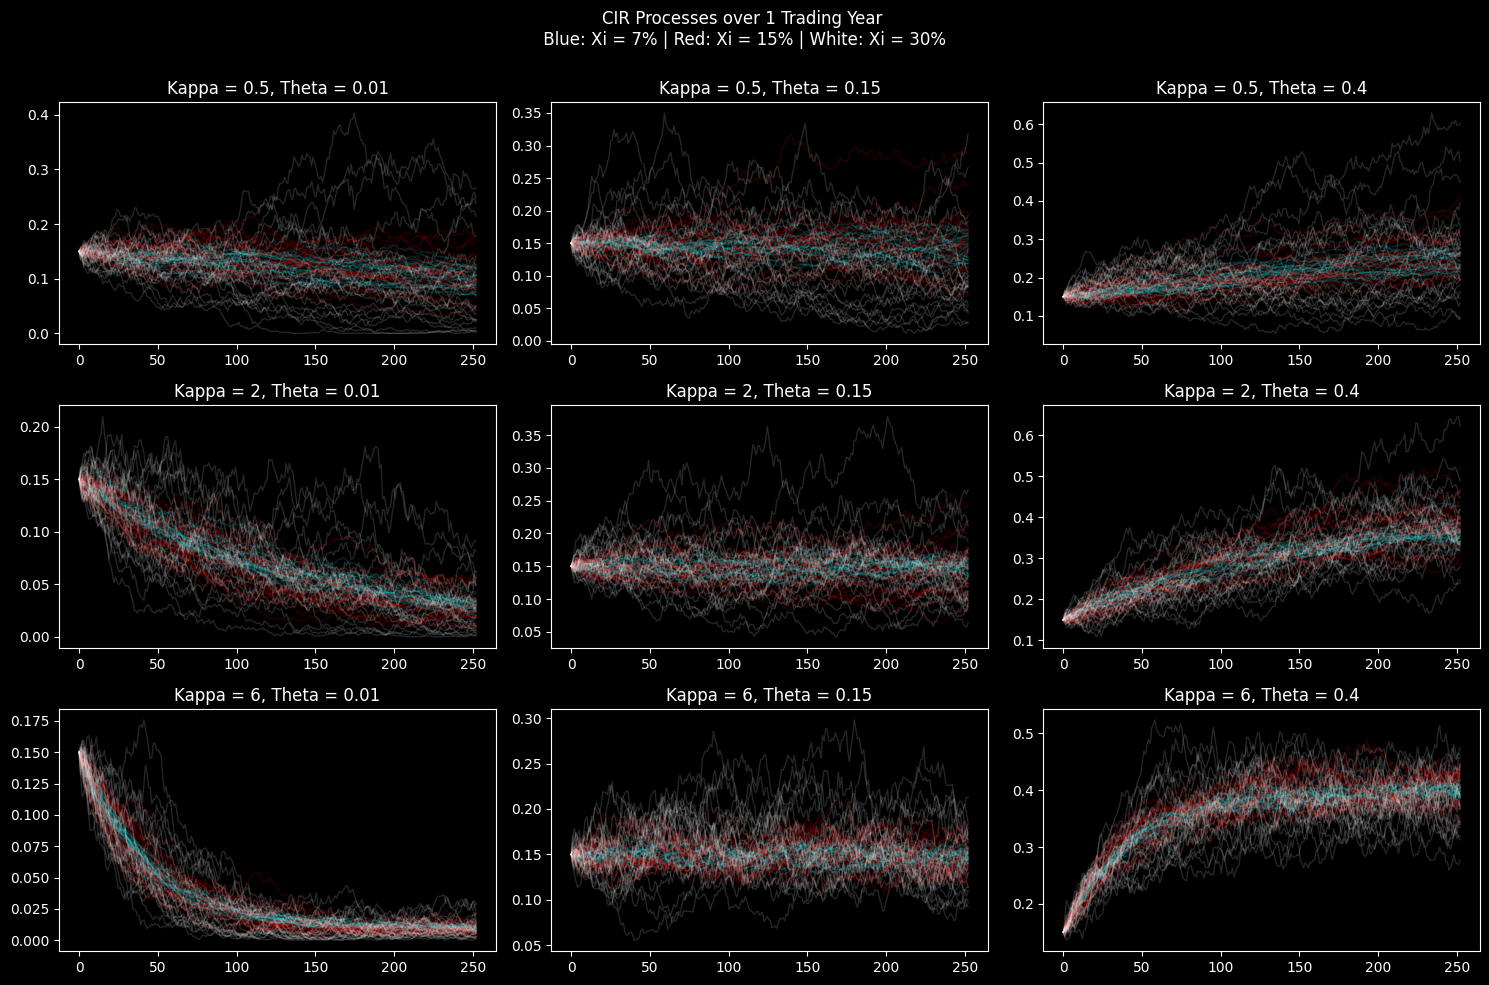

In [2]:
#Simulate dynamics of volatility under the CIR process

def CIR(kappa, theta, xi, rng):
    """Creates a CIR path.
       Takes in the mean reverting coefficient (kappa), long-term mean (theta), and vol-of-vol (xi) terms as inputs,
       outputs a list of 252 points (1 year) which follow the CIR Process with dt = 1 day, and starting volatility of 15%"""
    # if (2 * kappa * theta < xi ** 2):
    #     raise ValueError(f"Feller condition violated")
    
    path = np.zeros(252)
    dt = 1/252
    path[0] = 0.15

    dof = (4 * kappa * theta) / (xi ** 2)
    non_centrality_param = (4 * kappa * np.exp(-1 * kappa * dt)) / ((xi ** 2) * (1 - np.exp(-1 * kappa * dt)))
    c = ((xi **2) * (1 - np.exp(-1 * kappa * dt))) / (4 * kappa)

    for i in range (1, 252):
        x = rng.noncentral_chisquare(df = dof, nonc = non_centrality_param * path[i - 1])
        path[i] = c * x

    return path

#Create sample values
kappas = [0.5, 2, 6]
thetas = [0.01, 0.15, 0.40]
xis = [0.07, 0.15, 0.3]
rng = np.random.default_rng(seed = 100)

x = np.linspace(0, 252, 252)
plt.style.use('dark_background')
fig, ax = plt.subplots(3, 3, figsize = (15, 10))

colors = ['cyan', 'red', 'white']

for i, k in enumerate(kappas):
    for j, t in enumerate(thetas):
        for xi_idx, xi in enumerate(xis):
            for _ in range(25):
                ax[i, j].plot(x, CIR(k, t, xi, rng), color = colors[xi_idx], alpha = 0.15, linewidth = 1)
        ax[i, j].set_title(f'Kappa = {k}, Theta = {t}')

plt.suptitle("CIR Processes over 1 Trading Year \n Blue: Xi = 7% | Red: Xi = 15% | White: Xi = 30% \n ")
plt.tight_layout()

plt.show()

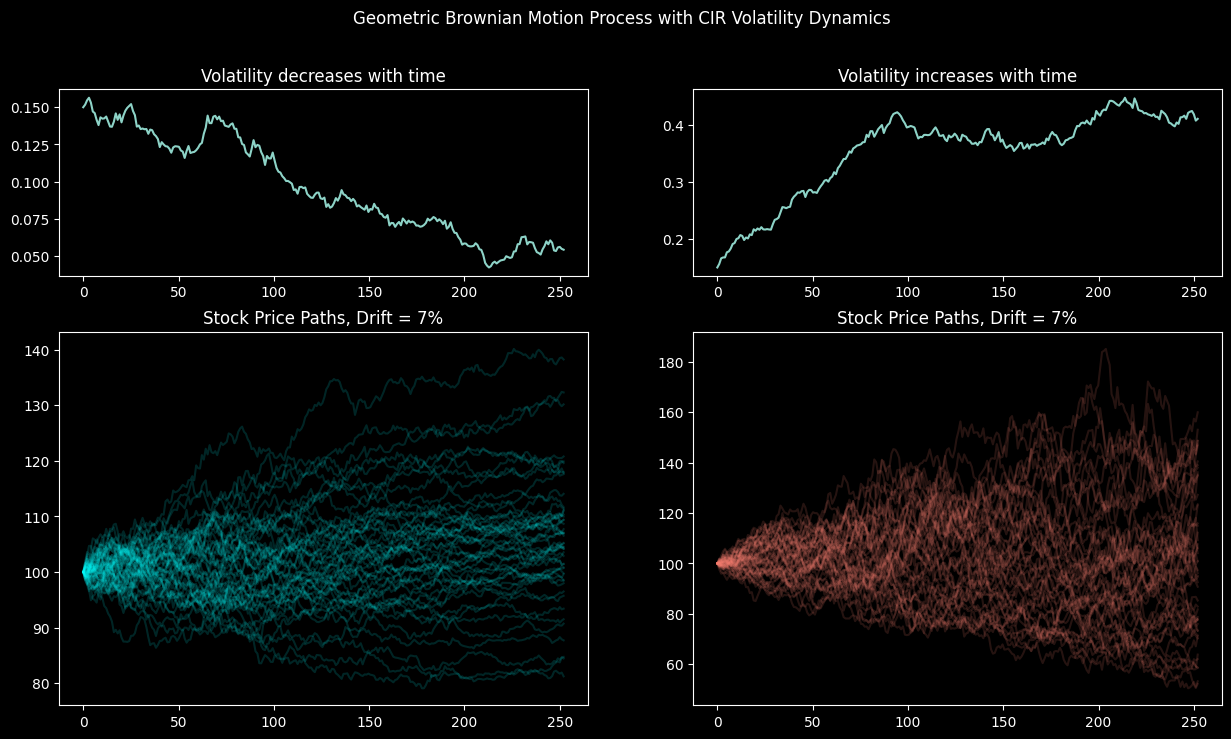

In [3]:
#Simulate a stock price under CIR volatility dynamics

def gbm(mu, v):
    """Creates a Geometric Brownian Motion path.
       Takes in the drift (mu) and volatility (v) terms as inputs, v is a list
       outputs a list of 252 points (1 year) which follow the GBM Process with dt = 1 day, and starting price of $100"""
    path = np.zeros(252)
    dt = 1/252
    path[0] = 100
    
    for i in range (1, 252):
        z = np.random.normal(0, 1)
        path[i] = path[i - 1] * np.exp((mu - 0.5 * v[i]**2) * dt + v[i] * np.sqrt(dt) * z) 
    
    return path

rng = np.random.default_rng(seed = 100)
vol = [CIR(2, 0.02, 0.15, rng), CIR(2, 0.45, 0.15, rng)]

x = np.linspace(0, 252, 252)
fig, ax = plt.subplots(2, 2, figsize = (15, 8), gridspec_kw = {'height_ratios': [1, 2]})

ax[0, 0].plot(x, vol[0])
ax[0, 0].set_title(f'Volatility decreases with time')
for i in range(50):
    ax[1, 0].plot(x, gbm(0.07, vol[0]), color = 'cyan', alpha = 0.15)
ax[1, 0].set_title(f'Stock Price Paths, Drift = 7%')

ax[0, 1].plot(x, vol[1])
ax[0, 1].set_title(f'Volatility increases with time')
for i in range(50):
    ax[1, 1].plot(x, gbm(0.07, vol[1]), color = 'salmon', alpha = 0.15)
ax[1, 1].set_title(f'Stock Price Paths, Drift = 7%')

plt.suptitle("Geometric Brownian Motion Process with CIR Volatility Dynamics")

plt.show()

***

Now, an option with value $V$ will be defined:
$$V = V(t, S_t, v_t; r, K, T)$$
where $r$, $K$ (strike price), and $T$ (time to maturity) are constants in this scenario.

In the Black Scholes model, because there was only one source of randomness, it could be hedged away using only *delta-hedging*. By contrast, in the Heston model, both the stock price and volatility contribute their own source of randomness. Thus, the hedging strategy now involves two parts: **Delta and Sigma hedging**, where sigma hedging refers to hegding against changing volatility.

Using Itô's Lemma, the differential of $V$ can be derived (noting that, since $V$ is a function of two random processes, the two-dimensional version of the Lemma must be used, which simply adds the partial derivatives of each random process and a cross term):
$$dV = \frac{\partial V}{\partial t}dt + \frac{\partial V}{\partial S_t}dS_t + \frac{1}{2}\frac{\partial^2 V}{\partial S^2_t}dS^2_t + \frac{\partial V}{\partial v_t}dv_t + \frac{1}{2}\frac{\partial^2 V}{\partial v^2_t}dv^2_t + \frac{\partial^2 V}{\partial S_t \partial v_t}dv_tdS_t$$
Next, the $dS^2_t$, $dv^2_t$, and $dv_tdS_t$ terms will be equated using standard Itô rules:
$$dS^2_t = \left(\mu S_t dt + \sqrt{v_t}S_t dW^S_t\right)^2 = vS^2_tdt$$
$$dv^2_t = \left(\kappa (\theta - v_t)dt + \xi\sqrt{v_t}dW^v_t\right)^2 = \xi^2v_tdt$$
$$dv_tdS_t = \left(\kappa (\theta - v_t)dt + \xi\sqrt{v_t}dW^v_t\right)\left(\mu S_t dt + \sqrt{v_t}S_t dW^S_t\right) = \rho\xi v_tS_tdt$$
where, for $dv_tdS_t$, when multiplying $dW^S_t$ and $dW^v_t$, the correlation coefficient must also be multiplied. This is because the two processes are not independent of each other, thus:
$$\mathbb{E}[dW^S_t \cdot dW^v_t] = Cov(dW^S_t, dW^v_t) + \mathbb{E}[dW^S_t]\mathbb{E}[dW^v_t]$$
but, $dW \sim \mathcal{N}(0, dt)$, thus the expected values of $dW^S_t$ and $dW^v_t$ are zero, while their variances are $dt$. Also, the formula for correlation coefficient is given by $\rho_{(X, Y)} = \frac{Cov(X, Y)}{\sigma_X\sigma_y}$, thus:
$$\mathbb{E}[dW^S_t \cdot dW^v_t] = \rho\sqrt{dt}\sqrt{dt} = \rho dt$$
*Note that, if the two Brownians are the same, their correlation is 1, therefore $dW\cdot dW = 1\cdot dt$*

Substituting these expressions into the equation for the options value, the following is obtained:
$$dV = \frac{\partial V}{\partial t}dt + \frac{\partial V}{\partial S_t}dS_t + \frac{1}{2}\frac{\partial^2 V}{\partial S^2_t}vS^2_tdt + \frac{\partial V}{\partial v_t}dv_t + \frac{1}{2}\frac{\partial^2 V}{\partial v^2_t}\xi^2v_tdt + \frac{\partial^2 V}{\partial S_t \partial v_t}\rho\xi v_tS_tdt$$
$$\Rightarrow dV = \left(\frac{\partial V}{\partial t} + \frac{1}{2}\frac{\partial^2 V}{\partial S^2_t}vS^2_t + \frac{1}{2}\frac{\partial^2 V}{\partial v^2_t}\xi^2v_t + \frac{\partial^2 V}{\partial S_t \partial v_t}\rho\xi v_tS_t\right)dt + \frac{\partial V}{\partial S_t}dS_t + \frac{\partial V}{\partial v_t}dv_t$$
For simplicity, let:
$$A_V = \frac{\partial V}{\partial t} + \frac{1}{2}\frac{\partial^2 V}{\partial S^2_t}vS^2_t + \frac{1}{2}\frac{\partial^2 V}{\partial v^2_t}\xi^2v_t + \frac{\partial^2 V}{\partial S_t \partial v_t}\rho\xi v_tS_t$$
$$\Rightarrow dV = A_Vdt + \frac{\partial V}{\partial S_t}dS_t + \frac{\partial V}{\partial v_t}dv_t$$
Next, substitute the $dS_t$ and $dv_t$ terms with their underlying stochastic dynamics:
$$dV = A_Vdt + \frac{\partial V}{\partial S_t}\left(\mu S_t dt + \sqrt{v_t}S_t dW^S_t\right) + \frac{\partial V}{\partial v_t}\left(\kappa (\theta - v_t)dt + \xi\sqrt{v_t}dW^v_t\right)$$
And, distributing terms and simplifying results in:
$$dV = \left(A_V + \frac{\partial V}{\partial S_t}\mu S_t + \frac{\partial V}{\partial v_t}\kappa (\theta - v_t)\right)dt + \frac{\partial V}{\partial S_t}\sqrt{v_t}S_t dW^S_t + \frac{\partial V}{\partial v_t}\xi\sqrt{v_t}dW^v_t$$

Now, let this option expire at time $T_1$ (i.e., $V = V(t, S_t, v_t; r, K, T_1)$). Additionally, since another asset is necessary in order to perform the two-legged hedging, assume the price of another option is also known, $U = U(t, S_t, v_t; r, K, T_2)$, which expires at time $T_2$, with the condition that $T_2 > T_1$ and that $U$ and $V$ are both written on the *same underlying stock*.  
$dU$ will be given by the same differential equation as for $dV$.

***

With that, a portfolio with value $\Pi$ can be constructed using the option $V$ along with the stock $S$ (which has been delta-hedged), and the other option $U$ (which has been sigma hedged).
$$\Pi = V - \Delta S_t - \Sigma U$$
$$\Rightarrow d\Pi = dV - \Delta dS_t - \Sigma dU$$
Substituting in the differentials results in:
$$\begin{align*} d\Pi &= \left(A_V + \frac{\partial V}{\partial S_t}\mu S_t + \frac{\partial V}{\partial v_t}\kappa (\theta - v_t)\right)dt + \frac{\partial V}{\partial S_t}\sqrt{v_t}S_t dW^S_t + \frac{\partial V}{\partial v_t}\xi\sqrt{v_t}dW^v_t\\ &- \Delta\left(\mu S_t dt + \sqrt{v_t}S_t dW^S_t \right) \\ &- \Sigma \left[\left(A_U + \frac{\partial U}{\partial S_t}\mu S_t + \frac{\partial U}{\partial v_t}\kappa (\theta - v_t)\right)dt + \frac{\partial U}{\partial S_t}\sqrt{v_t}S_t dW^S_t + \frac{\partial U}{\partial v_t}\xi\sqrt{v_t}dW^v_t \right] \end{align*}$$
And, distributing terms and simplifying results in:
$$\begin{align*} d\Pi &= \left[A_V + \frac{\partial V}{\partial S_t}\mu S_t + \frac{\partial V}{\partial v_t}\kappa (\theta - v_t)- \Delta\mu S_t - \Sigma\left(A_U + \frac{\partial U}{\partial S_t}\mu S_t + \frac{\partial U}{\partial v_t}\kappa (\theta - v_t)\right)\right]dt \\ &+ \sqrt{v_t}S_t\left(\frac{\partial V}{\partial S_t} - \Delta - \Sigma\frac{\partial U}{\partial S_t}\right)dW^S_t\\ &+ \xi\sqrt{v_t}\left(\frac{\partial V}{\partial v_t} - \Sigma\frac{\partial U}{\partial v_t}\right)dW^v_t \end{align*}$$

Next, the risk needs to be eliminated. In order to do that, the coefficients of the Brownian terms are simply set to zero:
$$\sqrt{v_t}S_t\left(\frac{\partial V}{\partial S_t} - \Delta - \Sigma\frac{\partial U}{\partial S_t}\right) = 0$$
$$\Rightarrow \Delta = \frac{\partial V}{\partial S_t} - \Sigma\frac{\partial U}{\partial S_t}$$
and
$$\xi\sqrt{v_t}\left(\frac{\partial V}{\partial v_t} - \Sigma\frac{\partial U}{\partial v_t}\right) = 0$$
$$\Rightarrow \Sigma = \frac{\partial V}{\partial v_t} \bigg/ \frac{\partial U}{\partial v_t}$$
Substituting in $\Delta$, the $dt$ term turns into:
$$A_V + \frac{\partial V}{\partial S_t}\mu S_t + \frac{\partial V}{\partial v_t}\kappa (\theta - v_t) - \left(\frac{\partial V}{\partial S_t} - \Sigma\frac{\partial U}{\partial S_t}\right)\mu S_t - \Sigma\left(A_U + \frac{\partial U}{\partial S_t}\mu S_t + \frac{\partial U}{\partial v_t}\kappa (\theta - v_t)\right)$$
$$= A_V + \frac{\partial V}{\partial v_t}\kappa(\theta - v_t) - \Sigma\left(A_U + \frac{\partial U}{\partial v_t}\kappa (\theta - v_t)\right)$$
And substituting in $\Sigma$, noting that both Brownian terms have been set to zero:
$$d\Pi = \left[A_V + \frac{\partial V}{\partial v_t}\kappa(\theta - v_t) - \frac{\partial V\big/\partial v_t}{\partial U \big/ \partial v_t}\left(A_U + \frac{\partial U}{\partial v_t}\kappa (\theta - v_t)\right)\right]dt$$
At this point, all randomness has been taken care of, and the portfolio is riskless.

Applying the no arbitrage condition (i.e., the condition that a portfolio that is riskless must also earn the risk-free rate such that there is no opportunity for any arbitrage):
$$d\Pi = r\Pi dt$$
And substituting in $\Delta$ and $\Sigma$ into to expression for the portfolio's value:
$$\Pi = V -\frac{\partial V}{\partial S_t}S_t + \frac{\partial V\big/\partial v_t}{\partial U \big/ \partial v_t}\left(\frac{\partial U}{\partial S_t}S_t - U\right)$$
Then, substituting this and the obtained $d\Pi$ expression into the no-arbitrage equation:
$$A_V + \frac{\partial V}{\partial v_t}\kappa(\theta - v_t) - \frac{\partial V\big/\partial v_t}{\partial U \big/ \partial v_t}\left(A_U + \frac{\partial U}{\partial v_t}\kappa (\theta - v_t)\right) = r\left[V -\frac{\partial V}{\partial S_t}S_t + \frac{\partial V\big/\partial v_t}{\partial U \big/ \partial v_t}\left(\frac{\partial U}{\partial S_t}S_t - U\right)\right]$$
Next, multiplying the equation by $\frac{\partial U}{\partial v_t}$ and simplifying gives:
$$\frac{\partial U}{\partial v_t}A_V - \frac{\partial V}{\partial v_t}A_U = \frac{\partial U}{\partial v_t}r\left(V - \frac{\partial V}{\partial S_t}S_t\right) + \frac{\partial V}{\partial v_t}r\left(\frac{\partial U}{\partial S_t}S_t - U\right)$$
Moving all terms with the same partial derivative coefficients to the same side yields:
$$\frac{\partial U}{\partial v_t}A_V - \frac{\partial U}{\partial v_t}rV + \frac{\partial U}{\partial v_t}\frac{\partial V}{\partial S_t}rS_t = \frac{\partial V}{\partial v_t}A_U - \frac{\partial V}{\partial v_t}rU + \frac{\partial V}{\partial v_t}\frac{\partial U}{\partial S_t}rS_t$$
Now, factoring out the partial derivatives and moving each to the other side gives:
$$\frac{A_V - rV + \frac{\partial V}{\partial S_t}rS_t}{\partial V\big/\partial v_t} = \frac{A_U - rU + \frac{\partial U}{\partial S_t}rS_t}{\partial U \big/ \partial v_t}$$

Notice that, if initally another option (say $W$) was chosen rather than $U$, the derivation would end up at the exact same endpoint, just with $W$'s rather than $U$'s. I.e.:
$$\frac{A_V - rV + \frac{\partial V}{\partial S_t}rS_t}{\partial V\big/\partial v_t} = \frac{A_W - rW + \frac{\partial W}{\partial S_t}rS_t}{\partial W \big/ \partial v_t}$$
Thus:
$$\frac{A_U - rU + \frac{\partial U}{\partial S_t}rS_t}{\partial U\big/\partial v_t} = \frac{A_W - rW + \frac{\partial W}{\partial S_t}rS_t}{\partial W \big/ \partial v_t}$$
and so on for *any* choice of option. This implies that both sides must equal some common function, $f$, which is a function of $t$, $S_t$, and $v_t$ (ignoring the other constant terms), but **not** of the actual option chosen. Therefore, the following can be written (a minus-sign has been introduced to make subsequent steps simpler):
$$\frac{A_V - rV + \frac{\partial V}{\partial S_t}rS_t}{\partial V \big/ \partial v_t} = -f(t, S_t, v_t)$$
where it is not necessary to choose $V$ as the option, but has been done so in this case.

Shifting some of the terms around gives:
$$A_V - rV = -\frac{\partial V}{\partial S_t}rS_t - \frac{\partial V}{\partial v_t}f$$
Now, taking note that $rS_t$ is the drift of the stock price (assuming, as this model does, that it is under the risk-neutral measure), a conclusion can be drawn that the function $f$ is the drift of the volatility. In order to- informally- derive an expression for $f$, recall the dynamics of the stock price and volatility:
$$dS_t = rS_t dt + \sqrt{v_t}S_t dW^{S, \mathbb{Q}}_t$$
$$dv_t = \kappa (\theta - v_t)dt + \xi\sqrt{v_t}dW^v_t$$
where $\mathbb{Q}$ indicates that the stock price's Brownian motion is under the risk-neutral measure and thus has a drift of $r$.

Now, to see the relationship between the risk under the real-world measure and the risk-neutral measure, the risk term can be rewritten as:
$$\frac{dS_t}{S_t} = \left(\mu - \frac{\mu - r}{\sqrt{v_t}}\sqrt{v_t}\right) dt + \sqrt{v_t} dW^{S, \mathbb{Q}}_t$$
noting that the drift term is simply equal to $r$, as in the original equation. Taking a closer look at that term, the ratio $\frac{\mu - r}{\sqrt{v_t}}$ is excess returns divided by volatility, which is also known as the **market price of risk**, a measure of how much units of excess returns (reward) are earned per unit risk (volatility) and is therefore also a measure of the amount of extra compensation an investor demands for bearing a certain amount of risk.  
*In the Black-Scholes model, this idea of market price of risk never shows up because the model assumes simpler dynamics, i.e. that there is only one source of randomness (risk) present. Hence, all of it could be eliminated via Delta-Hedging, and, ultimately, the drift term ($\mu$) disappears, and investors' risk preferences never appear in the final equation (in other words, the amount of expected returns- drift- than an investor might require to buy this option does not actually appear as a parameter to price the option). Importantly, in Black-Scholes the source of risk stems directly from a traded asset- the underlying stock- and can therefore be hedged away by trading that asset. However, in the Heston model, <u>variance is not a directly traded asset</u>. So, even though another option was introduced to eliminate this second source of risk from variance, it is not possible to replicate the market for this situation, leading to an inability to fully eliminate risk. Therefore, to find a single, mathematically consistent risk-neutral measure that matches the real-world, investors' risk appetite for bearing this unhedgable volatility risk (the market price of risk) must be parameterized and added to the Heston PDE, as will be shown in the subsequent derivations.*

Under the risk neutral measure, the stock-price SDE had its drift discounted by its market price of risk times the volatility term. Similarly, the market price of *volatility* risk can be defined as $\lambda$, then the variance SDE can be rewritten under the risk-neutral measure as:
$$dv_t = \left(\kappa (\theta - v_t) - \lambda \xi \sqrt{v_t}\right)dt + \xi\sqrt{v_t}dW^{v, \mathbb{Q}}_t$$
where $\xi\sqrt{v_t}$ is the complete volatility term since $\sqrt{v_t}$ could not be divided out as was done in the stock-price SDE.

Going back to the PDE, recall that:
$$R.H.S. = -\frac{\partial V}{\partial S_t}rS_t - \frac{\partial V}{\partial v_t}f$$
Then, it can be proposed that, since $rS_t$ is the drift of the stock price (under $\mathbb{Q}$) and is being multiplied with $\frac{\partial V}{\partial S_t}$, then $f$ is the risk-neutral drift of the volatility.  
Finally, setting $f$ equal to the risk-neutral drift of volatility and expanding $A_V$ gives the ***final Heston PDE***:
$$\boxed {\frac{\partial V}{\partial t} + \frac{1}{2}\frac{\partial^2 V}{\partial S^2_t}vS^2_t + \frac{1}{2}\frac{\partial^2 V}{\partial v^2_t}\xi^2v_t + \frac{\partial^2 V}{\partial S_t \partial v_t}\rho\xi v_tS_t + \frac{\partial V}{\partial S_t}rS_t + \frac{\partial V}{\partial v_t}\left(\kappa (\theta - v_t) - \lambda \xi \sqrt{v_t} \right) - rV = 0}$$

***

In order to derive the closed-form formula for the pricing of a Call option, first the risk-neutral measures are taken for the dynamics of the stock price and for volatility:
$$dS_t = rS_tdt + \sqrt{v}S_tdW^{S, \mathbb{Q}}_t$$
$$dv_t = \left(\kappa(\theta - v_t) - \lambda \xi \sqrt{v_t}\right)dt + \xi \sqrt{v_t}dW^{v, \mathbb{Q}}_t$$
where the drift term for $v_t$ can be simplified as:
$$dv_t = \left(\kappa(\theta - v_t) - \lambda v_t\right)dt + \xi \sqrt{v_t}dW^{v, \mathbb{Q}}_t$$
and setting the drift term equal to $\mu_v$:
$$dv_t = \mu_vdt + \xi \sqrt{v_t}dW^{v, \mathbb{Q}}_t$$
The price of a *European Call Option* can be expressed as a *risk-neutral expectation* along with its payoff function, $h$:
$$V_0 = \mathbb{E}^{\mathbb{Q}}\left[e^{-rT}h(S_T) | S_0, v_0\right], \qquad \textrm{where} ~~ h(S_T) = max\{S_T - K, 0\}$$
Next, let $x = \textrm{ln}S$, then, using the closed form for GBM:
$$e^{x_T} = e^{x_0}e^{\left[\left(\mu - \frac{1}{2}v_t\right)T + \sqrt{v_t}W_t\right]}$$
$$\Rightarrow x_T = x_0 + \left(\mu - \frac{1}{2}v_t\right)T + \sqrt{v_t}W_t$$
letting $x_T - x_0 \rightarrow dx$ and applying the risk-neutral measure:
$$dx = \left(r - \frac{1}{2}v_t\right)dt + \sqrt{v_t}dW^{S, \mathbb{Q}}_t$$
Substituting $\mu_v$ and $x$ into the Heston PDE, and canceling all the derivatives gives:
$$\frac{\partial V}{\partial t} + \frac{1}{2}\frac{\partial^2 V}{\partial x^2}v + \frac{1}{2}\frac{\partial^2 V}{\partial v^2_t}\xi^2v_t + \frac{\partial^2 V}{\partial x \partial v_t}\rho\xi v_t + \frac{\partial V}{\partial x}\left(r - \frac{1}{2}v\right) + \frac{\partial V}{\partial v_t}\mu_v - rV = 0$$
Next, $h(S_T)$ can be rewritten in terms of indicator functions (functions that equal 1 if the condition is met, and 0 otherwise):
$$h(S_T) = S_T1_{S_T > K} - K1_{S_T > K}$$
Then, substituting into the pricing function and writing the expectation of a sum as a sum of expectations:
$$V_0 = \mathbb{E}^{\mathbb{Q}}\left[e^{-rT}S_T1_{S_T > K}\right] - Ke^{-rT}\mathbb{E}^{\mathbb{Q}}\left[1_{S_T > K}\right]$$
In order to simplify the first terms, *change of numéraire* can be used, which, at a high level, is a method that simplifies the pricing of complex assets by switching to another "reference asset." Using the change of numéraire, the following two expressions can be derived:
$$\frac{V_0}{B_0} = \mathbb{E}^{\mathbb{Q}}\left[\frac{V_T}{B_T}\middle| \mathscr{F}_0\right] \qquad \frac{V_0}{S_0} = \mathbb{E}^{\mathbb{S}}\left[\frac{V_T}{S_T}\middle| \mathscr{F}_0\right]$$
where $B$ is the value of a back account that accrues the risk neutral payoff (and is thus under the $\mathbb{Q}$ measure), and $\mathbb{S}$ is the stock measure. A *filtration* ($\mathscr{F}$) is an increasing sequence of information gathered over time, and represents everything known about a random process up until a specific time (in this case the time $t = 0$, indicated by the subscript on the $\mathscr{F}$). Since the only known information is up until time 0 and not anything later, it indicates that both expectations are *Martingales*, where the expected value of the next state given all past information is exactly the current state.  
Moving some constants around:
$$V_0 = \mathbb{E}^{\mathbb{Q}}\left[\frac{B_0}{B_T}V_T\middle| \mathscr{F}_0\right] \qquad V_0 = \mathbb{E}^{\mathbb{S}}\left[\frac{S_0}{S_T}V_T\middle| \mathscr{F}_0\right]$$
and since the two expressions are equal, the following equality is deduced:
$$\frac{B_0}{B_T}dW^{\mathbb{Q}}_t = \frac{S_0}{S_T}dW^{\mathbb{S}}_t$$
Next, note that the bank account starts at 1 ($B_0 = 1$), and grows at the rate $r$ ($B_T = e^{rT}$), thus:
$$S_Te^{-rT}dW^{\mathbb{Q}}_t = S_0dW^{\mathbb{S}}_t$$
Then substituting into the pricing function yields:
$$V_0 = S_0\mathbb{E}^{\mathbb{S}}\left[1_{S_T > K}\right] - Ke^{-rT}\mathbb{E}^{\mathbb{Q}}\left[1_{S_T > K}\right]$$
Now, both of the expectations simply represent the probability that each of the indicator functions attain their corresponding conditions, so the equation can be written in terms of probabilities:
$$V_0 = S_0P_1 - Ke^{-rT}P_2$$
where $P_1$ represents the probability that the stock price is above the strike price in the *stock measure*, and $P_2$ is the same but in the *risk-neutral measure*.  
Now, transforming into the reversed-time direction by introducing $\tau = T - t$, and substituting in $x$:
$$V_{\tau} = e^xP_1 - Ke^{-r\tau}P_2 \qquad and \qquad \frac{\partial V}{\partial t} = -\frac{\partial V}{\partial \tau}$$
Since $V$ solves the PDE and is a linear combination, then each of the terms of $V$ also solve the PDE. Thus, let $V_1 = e^xP_1$, and $V_2 = ke^{-r\tau}P_2$. The derivatives of $V_1$ are as follows:
$$\frac{\partial V_1}{\partial \tau} = e^x\frac{\partial P_1}{\partial \tau} \qquad \frac{\partial V_1}{\partial v_t} = e^x\frac{\partial P_1}{\partial v_t} \qquad \frac{\partial V_1}{\partial x} = e^xP_1 + e^x\frac{\partial P_1}{\partial x}$$
$$\frac{\partial^2 V_1}{\partial v_t^2} = e^x\frac{\partial^2 P_1}{\partial v_t^2} \qquad \frac{\partial^2 V_1}{\partial x^2} = e^xP_1 + 2e^x\frac{\partial P_1}{\partial x} + e^x\frac{\partial^2 P_1}{\partial x^2} \qquad \frac{\partial^2 V}{\partial x \partial v_t} = e^x\frac{\partial P_1}{\partial v_t} + e^x\frac{\partial^2 P_1}{\partial x \partial v_t}$$
Then, substituting these into the original PDE and simplifying gives:
$$\frac{\partial P_1}{\partial \tau} = \frac{1}{2}\frac{\partial^2 P_1}{\partial x^2}v + \frac{1}{2}\frac{\partial^2 P_1}{\partial v^2_t}\xi^2v_t + \frac{\partial^2 P_1}{\partial x \partial v_t}\rho\xi v_t + \frac{\partial P_1}{\partial x}\left(r + \frac{1}{2}v\right) + \frac{\partial P_1}{\partial v_t}(\mu_v + \rho \xi v)$$
Following the same steps for $P_2$ yields the following PDE (the calculations for the derivatives have been omitted for brevity):
$$\frac{\partial P_2}{\partial \tau} = \frac{1}{2}\frac{\partial^2 P_2}{\partial x^2}v + \frac{1}{2}\frac{\partial^2 P_2}{\partial v^2_t}\xi^2v_t + \frac{\partial^2 P_2}{\partial x \partial v_t}\rho\xi v_t + \frac{\partial P_2}{\partial x}\left(r - \frac{1}{2}v\right) + \frac{\partial P_2}{\partial v_t}\mu_v$$
These two PDEs are very similar, so they can be combined into one by introducing some indexed functions.  
First, note that $\mu_v = \kappa\theta - (\kappa + \lambda)v_t$. Then, the following can be introduced (with the index variable, $j \in \{1, 2\}$):
$$u_1 = \frac{1}{2}, \qquad u_2 = -\frac{1}{2}$$
$$b_1 = \kappa + \lambda -\rho\xi \qquad b_2 = \kappa + \lambda$$
$$\Rightarrow \frac{\partial P_j}{\partial \tau} = \frac{1}{2}\frac{\partial^2 P_j}{\partial x^2}v + \frac{1}{2}\frac{\partial^2 P_j}{\partial v^2_t}\xi^2v_t + \frac{\partial^2 P_j}{\partial x \partial v_t}\rho\xi v_t + \frac{\partial P_j}{\partial x}\left(r + u_jv\right) + \frac{\partial P_j}{\partial v_t}(\kappa\theta - b_jv)$$
Notice that $P_1$ and $P_2$ both represent probabilities that the stock price ends up above the strike price at maturity, so the initial condition is simply the indicator function: $P_0 = 1_{S_T > K}$. And, transforming into $x$: $P_0 = 1_{x_T > \textrm{ln}K}$.  
If the underlying distribution, $f(z)$, of $x$ were known, finding the probabilities would be as easy as solving $P_j = \int_{\textrm{ln}K}^{\infty}f_j(z)dz$. But, since $f$ is unknown, to solve the PDE, the *characteristic function* of the random variable $x$ will be found. In probability theory, the characteristic function of a random variable is a way to completely describe the distribution and behavior of the random variable. For a random variable $X$ with PDF $f(x)$, the characteristic function is defined as:
$$\phi_X(\omega ) = \mathbb{E}\left[e^{i\omega X}\right] = \int_{-\infty}^{\infty}f(x)e^{i\omega x}dx$$
Thus, the following are found:
$$\phi_1(\omega ) = \mathbb{E}^{\mathbb{S}}\left[e^{i\omega x_T}\big| S_0, v_0 \right] \qquad \phi_2(\omega ) = \mathbb{E}^{\mathbb{Q}}\left[e^{i\omega x_T}\big| S_0, v_0\right]$$
*Note that the characteristic function is simply the **Fourier Transform** of the random variable, but with a sign reversal.*

Next, by the *Feynman-Kac Theorem* (which will not be discussed in detail here), the following is derived:
$$\frac{\partial \phi_j}{\partial \tau} = \frac{1}{2}\frac{\partial^2 \phi_j}{\partial x^2}v_t + \frac{1}{2}\frac{\partial^2 \phi_j}{\partial v^2_t}\xi^2v_t + \frac{\partial^2 \phi_j}{\partial x \partial v_t}\rho\xi v_t + \frac{\partial \phi_j}{\partial x}\left(r + u_jv\right) + \frac{\partial \phi_j}{\partial v_t}(\kappa\theta - b_jv_t)$$
Now, looking at the PDE, since every term is simply constant or proportional to $v$, (i.e., no higher-degree terms of $v$ appear), that means that the PDE is *affine* in $v$. (Affine functions are linear functions plus a constant, such as $f(x) = ax + b$.) Also, since $\phi$ is exponential, taking derivatives preserves the exponential form (i.e., $\left(e^{ux}\right)' = ue^{ux}$). Thus, $\phi$ can be assumed to be in the form of:
$$\phi_j(x, v_t, \tau) = e^{C_j(\tau, \omega) + D_j(\tau, \omega)v_t + i\omega x}$$
Again, since the derivative of an exponential includes that exponential, the derivaives of $\phi$ are:
$$\frac{\partial \phi_j}{\partial \tau} = \left(\frac{\partial C_j}{\partial \tau} + \frac{\partial D_j}{\partial \tau}v_t\right)\phi_j \qquad \frac{\partial \phi_j}{\partial x} = i\omega \phi_j \qquad \frac{\partial \phi_j}{\partial v_t} = D_j\phi$$
$$\frac{\partial^2 \phi_j}{\partial x^2} = -\omega ^2\phi \qquad \frac{\partial^2 \phi_j}{\partial v_t^2} = D^2\phi \qquad \frac{\partial^2 \phi_j}{\partial v_t\partial x} = i\omega Df$$
Then, substituting these values into the PDE and simplifying yields:
$$\left(-\frac{\partial D_j}{\partial \tau} - \frac{1}{2}\phi^2 + \frac{1}{2}\xi^2D^2 + \rho\xi i\omega D + u_ji\omega - b_jD\right)v_t - \frac{\partial C}{\partial \tau} + ri\omega + \kappa\theta D = 0$$
If this equation must equal zero for every value of $v_t$, then the following must also be true:
$$-\frac{\partial D_j}{\partial \tau} - \frac{1}{2}\phi^2 + \frac{1}{2}\xi^2D^2 + \rho\xi i\omega D + u_ji\omega - b_j = 0, \qquad - \frac{\partial C}{\partial \tau} + ri\omega + \kappa\theta D = 0$$
The first equation is known as a *Riccati Equation*, which is a first-order ODE that is quadratic in the unknown function, and is in the form of $\frac{dy}{dx} = P(x) + Q(x)y + R(x)y^2$.  
At maturity (when $\tau = 0$) the value of $\phi$ will be known exactly, with no randomness, and that value is $e^{i\omega x}$, thus $C_j(0, \omega) = D_j(0, \omega) = 0 \Rightarrow \phi(x, v_t, 0) = e^{i\omega x}$, this is the *initial condition*.  
Solving the Riccati equation results in the following expression for $D_j$:
$$D_j(\tau, \omega) = \frac{d_j + b_j - i\rho \xi \omega}{\xi^2}\frac{1 - e^{d_j\tau}}{1 - g_je^{d_j\tau}}$$
$$\textrm{with} \quad d_j = \sqrt{\left(i\rho\xi\omega - b_j\right)^2 - \xi^2\left(2iu_j\omega - \omega^2\right)}, \qquad g_j = \frac{b_j - i\rho\xi\omega + d_j}{b_j - i\rho\xi\omega - d_j}$$
The second equation can be solved using simple integration, and yields the following equation for $C_j$ (with the same $d$ and $g$ values as above):
$$C_j(\tau, \omega) = ir\omega\tau + \frac{\kappa\theta}{\xi^2}\left[\left(d_j + b_j - i\rho\xi\omega\right)\tau - 2\text{ln}\left(\frac{1 - g_je^{d_j\tau}}{1 - g_j}\right)\right]$$
Recall that the characterisic function is actually the Fourier Transform of $x$, thus $P_j$ is essentially the *Inverse Fourier Transform* of $\phi_j$ (more specifically, $\phi_j$ should be transformed using the *Lévy Inversion Formula*, which exactly operates on characteristic functions to recover the underlying PDFs). Applying this to the characteristic function gives the following:
$$P_j = \frac{1}{2} + \frac{1}{\pi}\int_0^{\infty}\Re\left[\frac{e^{-i\omega \textrm{ln}K}\phi_j(\omega)}{i\omega}\right]d\omega$$
where the $\Re$ operator extracts the *real-part* of its complex-valued parameter.

Finally, the value of a *Call Option*, $C$, is given by:
$$\boxed{C = S_0P_1 - Ke^{-rT}P_2}$$
where:
$$\boxed{P_j = \frac{1}{2} + \frac{1}{\pi}\int_0^{\infty}\Re\left[\frac{e^{-i\omega \textrm{ln}K}\phi_j(\omega)}{i\omega}\right]d\omega} \qquad j \in \{1, 2\}$$
$$\boxed{\phi_j(\omega) = e^{C_j + D_jv_0 + i\omega \textrm{ln}S_0}}$$
$$\boxed{D_j = \frac{d_j + b_j - i\rho \xi \omega}{\xi^2}\frac{1 - e^{d_jT}}{1 - g_je^{d_jT}}, \qquad C_j = ir\omega T + \frac{\kappa\theta}{\xi^2}\left[\left(d_j + b_j - i\rho\xi\omega\right)T - 2\text{ln}\left(\frac{1 - g_je^{d_jT}}{1 - g_j}\right)\right]}$$
$$\boxed{d_j = \sqrt{\left(i\rho\xi\omega - b_j\right)^2 - \xi^2\left(2iu_j\omega - \omega^2\right)}, \qquad g_j = \frac{b_j - i\rho\xi\omega + d_j}{b_j - i\rho\xi\omega - d_j}}$$
$$\boxed{b_1 = \kappa + \lambda -\rho\xi \qquad b_2 = \kappa + \lambda}$$
$$\boxed{u_1 = \frac{1}{2} \qquad u_2 = -\frac{1}{2}}$$
And the value of a *Put Option*, $P$, is given by the rule of put-call-parity:
$$\boxed{P = C + Ke^{-rT} - S_0}$$
***

Just like the Black-Scholes Model, the Heston model is ***pricing model***, meaning it is primarily used to price derivatives (like options).  
*Note that $b_1$ and $b_2$ both depend on $\lambda$, the market price of risk. However, in the original derivation done by Heston, the market price of risk was absorbed into the constants $\kappa$ and $\theta$ when transitioning into the risk-neutral measure such that: $\kappa_{\mathbb{Q}} = \kappa_{\mathbb{S}} + \lambda$ and $\theta_{\mathbb{Q}} = \frac{\kappa_{\mathbb{S}}\theta_{\mathbb{S}}}{\kappa_{\mathbb{S}} + \lambda}$. So, for simplicity, when pricing an option:*
$$b_1 = \kappa - \rho\xi \qquad b_2 = \kappa$$

In [4]:
#Calculate option price within the Heston framework

def heston_price_original(S, K, r, T, rho, xi, kappa, theta, v0, option_type):
    """Calculates the theoretical fair price of a European options contract"""
    i = 1j
    u = np.array([0.5, -0.5])
    b = np.array([kappa - (rho * xi), kappa])

    def integrand(omega, k):
        d = np.sqrt((i * rho * xi * omega - b[k])**2 - (xi**2) * (2 * i * u[k] * omega - omega**2))
        g = (b[k] - i * rho * xi * omega + d) / (b[k] - i * rho * xi * omega - d)

        D = ((d + b[k] - i * rho * xi * omega) / (xi**2)) * ((1 - np.exp(d * T)) / (1 - g * np.exp(d * T)))
        C = (i * r * omega * T) + ((kappa * theta) / (xi**2)) * (T * (d + b[k] - i * rho * xi * omega) - 2 * np.log((1 - g * np.exp(d * T)) / (1 - g)))

        phi = np.exp(C + v0 * D + i * omega * np.log(S))

        return np.real((np.exp(-i * omega * np.log(K)) * phi) / (i * omega))

    P1 = 0.5 + (1 / np.pi) * quad(integrand, 0, 10000, args = (0,))[0]    #Integrate up to 10,000 rather than infinity for stability
    P2 = 0.5 + (1 / np.pi) * quad(integrand, 0, 10000, args = (1,))[0]

    call_price = S * P1 - K * np.exp(-r * T) * P2
    
    if (option_type.lower() == 'call'):
        return call_price
    
    else:
        return call_price - S + K * np.exp(-r * T)

***

The function above would ouput the theoretical fair price of an options contract given the necessary parameters. However, several of the parameters are difficult to find or otherwise completely unknown: $\rho$, $\kappa$, $\theta$, $\xi$, and $v_0$. Remember:
- $\rho$: Correlation between the Brownians of the volatility process and the stock process.
- $\kappa$: Mean-reversion rate for volatility.
- $\theta$: Long-term mean for volatility.
- $\xi$: Volatility of the volatility process.
- $v_0$: The current instantaneous volatility.

The Black-Scholes had a similar issue: the volatility of the the stock was unknown. With Black-Scholes, market prices were used to estimate the market-implied volatility. A similar approach will have to be employed for the Heston model, as well.  
Specifically, the following process is used to estimate the value for the parameters:
1. Obtain current options chain and current market prices.
2. Use market prices to calibrate the Heston Model.
    - First, arbitrarily choose the parameters, $\bm{\theta} = (v_0, \xi, \kappa, \theta, \rho)$, and compute the Heston price using those parameters.
    - Then, solve the optimization problem to obtain the market-implied Heston parameters:
    $$\min_{\bm{\theta}} \sum_i\left(C_i^{Heston} - C_i^{Market}\right)^2$$

In order to solve the minimization problem, an iterative algorithm will have to be used. There are myriad optimization algorithms, and, even in industry, several algorithms are used for calibrating the Heston model. The most common is known as the **Levenberg-Marquardt Algorithm**.

The foundation of the Levenberg-Marquardt Algorithm is **Gradient Descent**, a fundamental algorithm in optimization. The *gradient*, $\vec{\nabla}$, of a function $f: \mathbb{R}^n \rightarrow \mathbb{R}$ is given by a vector of all its partial derivatives:
$$\vec{\nabla} f = \begin{bmatrix}
{\partial f} \big/ {\partial x_1} \\
{\partial f}\big/{\partial x_2} \\ 
\vdots \\ 
{\partial f}\big/{\partial x_n} \end{bmatrix}$$
Most importantly, **the gradient of a function points in the direction of *steepest acsent* of that function** (keeping in mind that the gradient is simply a vector). Thus, given an arbitrary function, taking a step opposite of the gradient will produce a point "lower" than the previous point. It follows, then, that repeatedly taking steps in the direction of the negative gradient will ultimately culminate in a minimum of the function. ***In optimization, the overall goal is to minimize the loss function in order to obtain the parameters that produce the most optimal value.*** This is the basis of gradient descent, which is formulated as:
$$x_{\{i + 1\}} = x_{\{i\}} - \eta \vec{\nabla} f(x_{\{i\}})$$
Essentially, the "new" point $x_{\{i + 1\}}$ is calculated by taking the "old" point $x_{\{i\}}$ and stepping in the opposite directon gradient of their function $f$. Here, $\eta$ is the *step size* that every iteration will take, and is a *hyperparameter* set by the user during the validation stage. Bigger steps can lead to faster convergence, but run the risk of overshooting the miniumum leading to erratic convergence. Meanwhile, smaller step sizes can drastically increase the time it takes for convergence. One major issue arises with this algorithm, however: for many functions (including the Heston minimization function), different variables have different curvatures associated with them. For directions with steeper curvatures, a smaller step size is necessary; but for directions with shallower curvatures, a larger step size is better. Therefore, there may not even be an "optimal" $\eta$ that can be used in these cases.

That issue is solved by **Newton's Optimization Method**. This method utilizes the *Hessian*, $\nabla^2$, which is given by a matrix of all the second derivatives of the function:
$$\nabla^2 f = \begin{bmatrix}
\frac{\partial^2 f}{\partial x_1^2} && \frac{\partial^2 f}{\partial x_1 \partial x_2} && \ldots && \frac{\partial^2 f}{\partial x_1 \partial x_n} \\
\frac{\partial^2 f}{\partial x_2 \partial x_1} && \frac{\partial^2 f}{\partial x_2^2} && \ldots && \frac{\partial^2 f}{\partial x_2 \partial x_n} \\
\vdots && \vdots && \ddots && \vdots \\
\frac{\partial^2 f}{\partial x_n \partial x_1} && \frac{\partial^2 f}{\partial x_n \partial x_2} && \ldots && \frac{\partial^2 f}{\partial x_n^2} \\ \end{bmatrix}$$
Importantly, the Hessian matrix **describes the local curvature of the function**. With this information, Gradient Descent can be optimized upon:
$$x_{\{i + 1\}} = x_{\{i\}} - \left[\nabla^2 f(x_{\{i\}})\right]^{-1} \vec{\nabla} f(x_{\{i\}})$$
where the *inverted Hessian matrix* acts as the step size because, if the function has a large curvature at the point in question ( a large Hessian value), then a small step size is necessary, and vice versa. In fact, the Newton method is characterized as having *quadratic convergence*, while Gradient Descent *converges linearly*. That means that Newtons Method will converge much faster and will require much less iterations. However, this method has one major drawback: storing and computing all the values quickly becomes computationally intractable. For $n$ variables, the method requires $\Omicron(n^2)$ memory just to hold the Hessian matrix, additionally, computing the inverse and the multiplication requres $\Omicron(n^3)$ operatons just to solve *one* step.

The Levenberg–Marquardt algorithm aims to solve this by estimating the Hessian Matrix using the *Jacobian Matrix*.  
For a function $\mathbf{f}: \mathbb{R}^n \rightarrow \mathbb{R}^m$ that takes in as input a vector $\mathbf{x} = (x_1, \dots, x_n)$ and outputs a vector $\mathbf{f}(\mathbf{x}) = (f_1(\mathbf{x}), \dots, f_m(\mathbf{x}))$, the Jacobian matrix is defined as follows:
$$\textbf{J} = \begin{bmatrix}
\frac{\partial f_1}{\partial x_1} && \ldots && \frac{\partial f_1}{\partial x_n} \\
\vdots && \ddots && \vdots \\
\frac{\partial f_m}{\partial x_1} && \ldots && \frac{\partial f_m}{\partial x_n} \\ \end{bmatrix}$$
Then, the minimization function that is to be solved is the **Sum of Squared Errors** and can be defined as follows (where the vector $\bm{\theta}$ represents the vector containing all the parameters that are to be minimized, $y_i$ represents the *actual* value corresponding to point $x_i$, $f$ is the model function, and the $\frac{1}{2}$ is added to aid in simplification in the future):
$$M(\bm{\theta}) = \frac{1}{2}\sum_i\left[y_i - f(x_i, \bm{\theta})\right]^2 := \frac{1}{2}\sum_ir_i^2(\bm{\theta})$$
The gradient of $M$ can be calculated by taking the partial derivative of $M$ with respect to a single parameter, $\theta_j$ (the chain rule for $r_i^2$ must be used):
$$\frac{\partial}{\partial \theta_j}M = (\vec{\nabla}M)_j = \frac{1}{2}\sum_i 2r_i \frac{\partial r_i}{\partial \theta_j}$$
and, noting that $\frac{\partial r_i}{\partial \theta_j}$ is the $i^{th}$ row and $j^{th}$ column of the Jacobian matrix for $\mathbf{r}(\bm{\theta})$:
$$(\vec{\nabla}M)_j = \sum_i r_i J_{ij}$$
Then, stacking up the derivatives over every $j$ and collapsing the sum over all $i$ gives:
$$\vec{\nabla}M = \textbf{J}^T\mathbf{r}$$
To obtain an expression for the Hessian, again differentiate $(\vec{\nabla}M)_j$ with respect to another parameter, $\theta_k$, and apply the product rule:
$$\frac{\partial}{\partial \theta_k}\frac{\partial M}{\partial \theta_j} = (\nabla^2M)_{jk} = \sum_i \frac{\partial r_i}{\partial \theta_k}\frac{\partial r_i}{\partial \theta_j} + \frac{\partial^2 r_i}{\partial \theta_j \partial \theta_k}r_i$$
Finally, stacking over all $i$, $j$, $k$, the first term simplifies to $\textbf{J}^T\textbf{J}$, and the second terms contains the Hessian matrix of $r_i$ after stacking over all $j$, $k$:
$$\nabla^2M = \textbf{J}^T\textbf{J} + \sum_i r_i \nabla^2r_i$$
The $\nabla^2r_i$ is a second order term, so the Hessian can be estimated as:
$$\nabla^2M \approx \mathbf{J}^T\textbf{J}$$
Ultimately, the final Levenberg-Marquardt update algorithm proposes a blend of *Gradient Descent* and the *Newton Method* along with the approximations derived above:
$$\boxed{x_{\{i + 1\}} = x_{\{i\}} - \left[\textbf{J}^T\textbf{J} + \lambda \textbf{I}\right]^{-1} \textbf{J}^T\mathbf{r}(x_{\{i\}})}$$
where $\textbf{I}$ is the Identity Matrix.  
$\lambda$ is the parameter that influences how much the step is "akin" to either Gradient Descent vs. Newton's Method because, as $\lambda \rightarrow 0$, the update rule follows *Newton's Method*, while as $\lambda \rightarrow \infty$, *Gradient Descent* is recovered.  
When close to the minimum, the approximation for the Hessian works better because the residual errors ($r_i$'s) had been dropped in that approximation, thus using $\textbf{J}^T\textbf{J}$ is a good approximation for the Hessian near the solution, and the Newton Method is better to use. Meanwhile, Gradient Descent tends to take unnecessarily small steps or to oscillate when close to the solution, so Gradient Descent is better used further from the minimum. Therefore, the complete Levenberg-Marquardt update algorithm is as follows:
1. Update the function.
2. Evaluate the error at this new location.
3. If the error has decreased, the update can be accepted and $\lambda$ is decreased by several factors.
4. If the error has increased, the parameter vector is reset to the previous parameter values (i.e., the step is rejected) and $\lambda$ is increased by several factors.

**One major issue still remains with Levenberg-Marquardt algorithm: *How should the derivatives be calculated?***

The first option is to use the *analytical derivatives* of the pricing equation. Since the actual pricing equation does not depend directly on any of the parameters ($\kappa$, $\rho$, $v_0$, $\xi$, $\theta$), this reduces to finding the derivatives of the characteristic equation: $\vec{\nabla} \phi(\bm{\theta})$. To find the derivative of the characteristic function with respect to a single parameter, however, requires differentiating through several nested layer of equations. For example, just differentiating with respect to $\rho$ results in about **9** nested equations. And this would need to done for all 5 parameters just to obtain the gradient of the characteristic function. Therefore, industry generally considers using analytical derivatives as *intractable* for this situation (in fact, no explicit gradient of this equation has even been published).  

Another option is using *finite differences*. A derivative can be estimated using the central finite difference approximation:
$$\vec{\nabla} C(\bm{\theta}; K, T) \approx \frac{C(\bm{\theta} + \epsilon; K, T) - C(\bm{\theta} - \epsilon; K, T)}{2\epsilon}$$
This scheme does not require calculating any derivatives, and is thus much more tractable. Nonetheless, this option also presents a major issue: the computational expense. Each evaluation of $C$ requires the computer to numerically compute 2 integrals ($P_1$ and $P_2$); the finite differences approximation requires 2 calls to $C$; and the approximation would need to be calculated for each of the 5 parameters. Ultimately, this results in 20 integrals per derivative. Furthermore, these 20 integrals would have to be done for *each* option in the residual vector, $\textbf{r}$, which can easily contain more than 40 residuals (i.e., more than 800 integrals would have to be numerically calculated). Even further, the finite difference method would create a noisier gradient surface, slowing down convergence compared to using an analytical gradient (i.e., more iterations would be needed for the finite difference method).

As it happens, a paper published by *Cui, et. al.* in 2017 introduces an alternative, algabraically equivalent version of the characterisic equation that allows for a much more tractable derivation of the gradient (and also solves several other issues present with the original Heston equation):
$$\phi(\bm{\theta}; \omega, T) = \textrm{exp}\left[i\omega(\textrm{ln}S_0 + rT) - \frac{T\kappa\theta\rho i\omega}{\xi} - v_0A + \frac{2\kappa\theta}{\xi^2}D\right]$$
where:
$$A = \frac{(\omega^2 + i\omega)\textrm{sinh}\frac{Td}{2}}{d\textrm{cosh}\frac{Td}{2} + \alpha\textrm{sinh}\frac{Td}{2}} := \frac{A_1}{A_2}$$
$$D = \textrm{ln}d + \frac{(\kappa - d)T}{2} - \textrm{ln}\left(\frac{d + \alpha}{2} + \frac{d - \alpha}{2}e^{-Td}\right)$$
$$d = \sqrt{\alpha^2 + \xi^2(\omega^2 + i\omega)}$$
$$\alpha = \kappa - \xi\rho i\omega$$
The derivatives with respect to $v_0$ and $\theta$ are simple:
$$\frac{\partial \phi}{\partial v_0} = -A\phi$$
$$\frac{\partial \phi}{\partial \theta} = \left(-\frac{T\kappa\rho i\omega}{\xi} + \frac{2\kappa D}{\xi^2}\right)\phi$$
For the derivatives with respect to the other parameters, common intermediate derivatives can be defined using the auxillary variable $u$ (where $u$ is a stand-in for $\kappa$, $\rho$, and $\xi$):
$$\frac{\partial A}{\partial u} = \frac{\frac{\partial A_1}{\partial u}A_2 - \frac{\partial A_2}{\partial u}A_1}{A^2_2}$$
$$\frac{\partial A_1}{\partial u} = (\omega^2 + i\omega)\frac{T}{2}\frac{\partial d}{\partial u}\textrm{cosh}\frac{Td}{2}$$
$$\frac{\partial A_2}{\partial u} = \frac{\partial d}{\partial u}\left(\textrm{cosh}\frac{Td}{2} + \frac{Td}{2}\textrm{sinh}\frac{Td}{2} + \frac{T\alpha}{2}\textrm{cosh}\frac{Td}{2}\right) + \frac{\partial \alpha}{\partial u}\textrm{sinh}\frac{Td}{2}$$
$$\frac{\partial D}{\partial u} = \frac{\partial d}{\partial u}\left(\frac{1}{d} - \frac{T}{2}\right) - \frac{\frac{\partial d}{\partial u} + \frac{\partial \alpha}{\partial u} + e^{-Td}\left(\frac{\partial d}{\partial u}(1 - Td + T\alpha) - \frac{\partial \alpha}{\partial u}\right)}{d + \alpha + e^{-Td}(d - \alpha)} + \frac{\partial}{\partial u}\left[\frac{\kappa T}{2}\right]$$
$$\frac{\partial d}{\partial u} = \frac{2\alpha\frac{\partial \alpha}{\partial u} + \frac{\partial}{\partial u}\left[\xi^2(\omega^2 + i\omega)\right]}{2\sqrt{\alpha^2 + \xi^2(\omega^2 + i\omega)}}$$
The derivatives with respect to $\alpha$ are simple:
$$\frac{\partial \alpha}{\partial \kappa} = 1 \qquad \frac{\partial \alpha}{\partial \rho} = -\xi i\omega \qquad \frac{\partial \alpha}{\partial \xi} = -\rho i\omega$$
And, likewise for the derivatives of the actual characteristic equation:
$$\frac{\partial \phi}{\partial \kappa} = \left[-\frac{T\theta\rho i\omega}{\xi} - v_0\frac{\partial A}{\partial \kappa} + \frac{2\theta}{\xi^2}\left(D + \kappa\frac{\partial D}{\partial \kappa}\right)\right]\phi$$
$$\frac{\partial \phi}{\partial \rho} = \left[-\frac{T\theta\kappa i\omega}{\xi} - v_0\frac{\partial A}{\partial \rho} + \frac{2\theta\kappa}{\xi^2}\frac{\partial D}{\partial \rho}\right]\phi$$
$$\frac{\partial \phi}{\partial \xi} = \left[\frac{T\theta\kappa\rho i\omega}{\xi^2} - v_0\frac{\partial A}{\partial \xi} + \frac{2\kappa\theta}{\xi^2}\left(-\frac{2D}{\xi} + \frac{\partial D}{\partial \xi}\right)\right]\phi$$
Also recall that the derivatives of the probability expressions would also have to be taken:
$$\frac{\partial P_j}{\partial u} = \frac{1}{\pi}\int_0^{\infty}\Re\left[\frac{e^{-i\omega \textrm{ln}K}\frac{\partial \phi_j}{\partial u}}{i\omega}\right]d\omega$$
In order to further speed up convergence, Cui, et. al. suggests a different approach for the numeric computations of the integrals: using the *Gauss-Legendre Quadrature* rather than trapezoidal sums or Reimann sums.  
The goal is to approximate an integral using a sum:
$$\int_a^b f(x)dx \approx \sum_{i = 1}^Nw_if(x_i)$$
for weights $w_k$ and $N$ distinct nodes.  
The GL scheme posits that, if the position of the nodes are chosen freely- as opposed to equidistantly spaced- then a polynomial of up to order $2N - 1$ can be exactly integrated with $N$ nodes.  
First, the points $x_i$ need to be found. These points are the roots (zeros) of the $n$-th degree *Legendre Polynomial*, which are a sequence of orthogonal polynomials. The $n$-th degree Legendre polynomial is denoted as $P_n(x)$ and is found using Rodrigues' formula:
$$P_n(x) = \frac{1}{2^nn!}\frac{d^n}{dx^n}(x^2 - 1)^n$$
The first three Legendre polynomials are (where each of the roots corresponds to an $x_i$):  
$P_1(x) = x$    Roots: $\{0\}$  
$P_2(x) = \frac{1}{2}(3x^2 - 1)$    Roots: $\{\pm\sqrt{\frac{1}{3}}\}$  
$P_3(x) = \frac{1}{2}(5x^3 - 3x)$   Roots: $\{0, \pm\sqrt{\frac{1}{3}}\}$  
Orthogonal polynomials are a set of polynomials for which any two of their inner products equals zero over a specific interval. For Legendre polynomials, that interval is $[-1, 1]$:
$$\int_{-1}^1P_n(x)P_m(x)dx = 0 \quad for ~ m\neq n$$
Each of the weights $w_i$ are calculated using the derivative of the Legendre polynomial:
$$w_i = \frac{2}{(1 - x_i^2)\left[P'_n(x_i)\right]^2}$$
And, finally, since the quadrature is only defined on the interval $[-1, 1]$, a change of variables is necessary to integrate over an arbitrary interval $[a, b]$:
$$x = \frac{b - a}{2}t + \frac{a + b}{2} ~ \Rightarrow ~ dx = \frac{b - a}{2}dt \qquad \text{for} ~ t \in [-1, 1] ~ \text{and} ~ x \in [a, b]$$
Thus:
$$\int_a^b f(x)dx \approx \frac{b - a}{2}\sum_{i = 1}^Nw_i f\left(\frac{b - a}{2}x_i + \frac{a + b}{2}\right)$$
The upper bound for the Heston integral is $\infty$, but the integrand decays quickly and is negligible past a certain $b$, usually beyond 200, depending on the necessity.  
Recall that the sum would be exact if $f$ were a polynomial of degree $2N - 1$ or less. However, the Heston characteristic function *is not a polynomial* (rather, it is exponential). However, the usage of a polynomial is not a requirement, but rather just a criteria for exactness. Further, any sufficiently smooth function can be approximated using a polynomial (the basis of theorems such as the Taylor expansion/approximation). 

***

The Heston pricing formula with the alternative characteristic function proposed by Cui, et. al. will be implemented below (all integrals will be taken using the Gauss-Legendre quadrature):
$$C = \frac{1}{2}\left(S_0 - e^{-rT}K\right) + \frac{e^{-rT}}{\pi}\left(\int_0^{\infty}\Re\left[\frac{e^{-i\omega\textrm{ln}K}}{i\omega}\phi(\bm{\theta}, \omega - i, T)\right]d\omega - K\int_0^{\infty}\Re\left[\frac{e^{-i\omega\textrm{ln}K}}{i\omega}\phi(\bm{\theta}, \omega , T)\right]d\omega\right)$$

In [5]:
#Calculate option price within the Heston framework using the alternative characteristic function

def heston_price_optimized(S, K, r, T, rho, xi, kappa, theta, v0, option_type):
    """Calculates the theoretical fair price of a European options contract using an alternative characteristic equation,
       also optimized to accept series inputs as K and T"""
    i = 1j

    # Convert inputs to arrays and add a new axis to align shapes: (M,) -> (M, 1)
    K = np.atleast_1d(K)[:, None]
    T = np.atleast_1d(T)[:, None]

    def char_eq(omega):
        alpha = kappa - xi * rho * i * omega
        d = np.sqrt(alpha ** 2 + (omega ** 2 + i * omega) * xi ** 2)
        
        A = ((omega ** 2 + i * omega) * np.sinh(0.5 * T * d)) / (d * np.cosh(0.5 * T * d) + alpha * np.sinh(0.5 * T * d))
        D = np.log(d) + (0.5 * T * (kappa - d)) - np.log(0.5 * (d + alpha) + 0.5 * np.exp(-1 * T * d) * (d - alpha))
        
        phi = np.exp((i * omega * (np.log(S) + r * T)) - ((T * kappa * theta * rho * i * omega) / (xi)) - (v0 * A) + ((2 * kappa * theta * D) / (xi ** 2)))

        return phi

    def P1_integrand(omega):
        arg = ((np.exp(-1 * i * omega * np.log(K))) / (i * omega)) * char_eq(omega - i)

        return np.real(arg)

    def P2_integrand(omega):
        arg = ((np.exp(-1 * i * omega * np.log(K))) / (i * omega)) * char_eq(omega)
    
        return np.real(arg)

    def gauss_legendre_integral(func, a, b, N):
        """func is the function which is to be integrated; a is the lower bound; b is the upper bound, 
           and N is the number of nodes"""
        roots, weights = np.polynomial.legendre.leggauss(N)

        # Add axes to roots and weights: (N,) -> (1, N)
        roots = roots[None, :]
        weights = weights[None, :]

        x = 0.5 * (b - a) * roots + 0.5 * (b + a)
        w = 0.5 * (b - a) * weights

        return np.sum(w * func(x), axis = 1, keepdims = True)

    #The integrals decay quickly, and as T increases, the upper bound can decrease in order to assure convergence within 10^-8
    #In this case, using b = 50 / sqrt(T) is sufficient
    P1 = gauss_legendre_integral(P1_integrand, 0, 50 / np.sqrt(T), 60)
    P2 = gauss_legendre_integral(P2_integrand, 0, 50 / np.sqrt(T), 60) 

    call_price = 0.5 * (S - K * np.exp(-1 * r * T)) + ((np.exp(-1 * r * T)) / (np.pi)) * (P1 - K * P2)
    put_price = call_price - S + K * np.exp(-r * T)

    # Flatten option_type to match the output array shape
    option_type_arr = np.atleast_1d(option_type)[:, None]
    prices = np.where(np.char.lower(option_type_arr.astype(str)) == 'call', call_price, put_price)
    
    return prices.flatten()

Some final considerations before the algorithm can be implemented:  
Options at different strikes have very different sensitivities to volatility, especially those deep out-of-the-money (OTM) since the further the option is from at-the-money (ATM), the less it contributes to the loss function. Thus, minimization will push the ATM price residuals closer to zero while tolerating larger OTM residuals, whereas the goal is to achieve convergence to zero everywhere.  
This issue can be fixed by *correcting by **vega***, the option's sensitivity to implied volatility. Recall that, according to Black-Scholes, vega is defined as:
$$\nu = \frac{\partial V}{\partial \sigma} = S\sqrt{T}\phi\left(\frac{\textrm{ln}\left(\frac{S}{K}\right) + T\left(r + \frac{1}{2}\sigma^2\right)}{\sigma\sqrt{T}}\right)$$
where $\phi(\cdot)$ is the standard normal probability density funtion and $\sigma$ is the **market-quoted** implied volatility.  
Then both the residual and, therefore, the Jacobian are corrected by $\frac{1}{\nu}$ before being fed into the LM update step:
$$\tilde{r}_i(\bm{\theta}) = \frac{1}{\nu_i}(C^{market}_i - C^{Heston}_i(\bm{\theta}; K_i, T_i, r)), \qquad \tilde{J_{ji}} = \frac{1}{\nu_i}J_{ji}$$
As for the initial guess, some will not be random but rather informed heuristics:
$$\theta_{init} = \sigma_{ATM, Long} \quad v_{0_{init}} = \sigma_{ATM, Short} \quad \xi_{init} = 0.4 \quad \rho_{init} = -0.6$$
and $\kappa_{init}$ will be selected using the Feller Condition:
$$2\kappa_{init}\theta > \xi^2$$
where the initial $\theta$ is set to the ATM IV with a long-dated maturity, the initial $v_0$ is set to the shortest-term ATM IV, and $\xi$ and $\rho$ are initialized randomly.

Below, the Levenberg-Marquardt algorithm will be implemented from scratch; the Heston model will be calibrated on a user-defined stock/ETF:

In [6]:
#Define function to extract market option prices for a user defined stock

def extract_market_prices(r):
    """Creates a dataframe with all market option prices (calls and puts) 
       for a user defined stock across all expiry dates and strike prices
       The input is the risk-free-rate, for vega calculations,
       The output is a tuple: (Options Chain, current price)"""

    #Get user input for stock
    stock = input("Input a ticker: ").upper()
    ticker = yf.Ticker(stock)
    while (True):
        try:
            info = ticker.info
            if (not info or info.get('regularMarketPrice') is None):
                raise ValueError
        except Exception:
            stock = input("Input a valid ticker: ").upper()
            ticker = yf.Ticker(stock)
            continue
        break

    #Create the Dataframe that contains all expiry dates of the corresponding stock
    S = ticker.fast_info.last_price
    expiries = pd.DataFrame(ticker.options, columns = ['Expiries'])
    today = (pd.Timestamp.today() + pd.Timedelta(days = 1)).normalize()   #"normalize" ensures the time starts at midnight, and starting at tomorrow at midnight ensures 'Last Trade Day' doesn't produce negative values
    expiries['Time To Expiry'] = (pd.to_datetime(expiries['Expiries']) - today) / pd.Timedelta(days = 365)    #Subtracting dates in Pandas results in a 'TimeDelta' object
    expiries['Time To Expiry'] = expiries['Time To Expiry'].astype(float)

    #Add all options data to a dataframe
    temp_list = []
    for expiry, time in zip(expiries['Expiries'], expiries["Time To Expiry"]):
        #Create temporary dataframes with the chain for each expiry. All of these data frames will be concatenated in the end

        call_chain = ticker.option_chain(expiry).calls
        temp_list.append(pd.DataFrame({'Strike': call_chain['strike'], 
            'Time To Expiry': time, 
            'Price': call_chain['lastPrice'], 
            'Type': 'Call',
            'IV': call_chain['impliedVolatility'],
            'Vega': (S * norm.pdf((np.log(S / call_chain['strike']) + time * (r + 0.5 * call_chain['impliedVolatility']**2)) / (call_chain['impliedVolatility'] * np.sqrt(time))) * np.sqrt(time)),
            'Days Since Trade': call_chain['lastTradeDate'],
            'Bid': call_chain['bid'],
            'Ask': call_chain['ask']}))

        put_chain = ticker.option_chain(expiry).puts
        temp_list.append(pd.DataFrame({'Strike': put_chain['strike'], 
            'Time To Expiry': time, 
            'Price': put_chain['lastPrice'], 
            'Type': 'Put',
            'IV': put_chain['impliedVolatility'],
            'Vega': (S * norm.pdf((np.log(S / put_chain['strike']) + time * (r + 0.5 * put_chain['impliedVolatility']**2)) / (put_chain['impliedVolatility'] * np.sqrt(time))) * np.sqrt(time)),
            'Days Since Trade': put_chain['lastTradeDate'],
            'Bid': put_chain['bid'],
            'Ask': put_chain['ask']}))

    chain = pd.concat(temp_list, ignore_index = True)

    chain['Days Since Trade'] = (today - pd.to_datetime(chain['Days Since Trade'].dt.tz_localize(None))) / pd.Timedelta(days = 1)
    chain['Days Since Trade'] = np.round(chain['Days Since Trade'].astype(float))
    chain = chain.drop(chain[chain['Days Since Trade'] > 10].index)     #Delete any option that hasn't been traded in the past 10 days 
    chain = chain.drop(chain[chain['Vega'] < 0.01].index)    #Delete any option with a vega too low
    chain = chain.dropna()
    # chain = chain.drop(columns = ['Days Since Trade'])
    chain = chain.reset_index(drop = True)

    return (chain, S)

Recall that the residual vector is calculated as follows:
$$\textbf{r} = \textbf{r}(\bm{\theta}) = \textbf{V}^{Heston}(\bm{\theta}; T, K, r, S_0) - \textbf{V}^{Market}$$
with
$$\bm{\theta} = \langle\rho, \xi, \kappa, v_0, \theta\rangle

In [7]:
#Define function to calculate the residuals

def calc_residuals(market_options_chain, current_price, rho, xi, kappa, theta, v0, r):
    """Using the inputted market data and calculated Heston prices, a dataframe with the residuals will be calculated"""

    heston_option_prices = pd.DataFrame(columns = ['Heston Price'])
    
    #Calculate all the prices using the information from the given market data dataframe and parameters
    heston_option_prices['Heston Price'] = heston_price_optimized(current_price, market_options_chain['Strike'],
                                            r, market_options_chain['Time To Expiry'], 
                                            rho, xi, kappa, theta, v0, market_options_chain['Type'])

    #Calculate residuals
    residuals = pd.DataFrame({'Residuals': heston_option_prices['Heston Price'] - market_options_chain['Price'], 
                              'Time To Expiry': market_options_chain['Time To Expiry'],
                              'Strike': market_options_chain['Strike'],
                              'Vega': market_options_chain['Vega']})
    residuals['Residuals'] = (1 / residuals['Vega']) * residuals['Residuals']
    
    return residuals

Recall that the Jacobian matrix is calculated as follows:

$$\textbf{J} = \begin{bmatrix} \frac{\partial r_1}{\partial \rho} & \frac{\partial r_1}{\partial \kappa} & \frac{\partial r_1}{\partial \theta} & \frac{\partial r_1}{\partial \xi} & \frac{\partial r_1}{\partial v_0} \\
\vdots & \vdots & \vdots & \vdots & \vdots \\
\frac{\partial r_n}{\partial \rho} & \frac{\partial r_n}{\partial \kappa} & \frac{\partial r_n}{\partial \theta} & \frac{\partial r_n}{\partial \xi} & \frac{\partial r_n}{\partial v_0} \end{bmatrix}$$
where $\textbf{J}$ is of size $n \times 5$ ($n$ options and $5$ parameters), and $\textbf{r} = \langle r_1(\bm{\theta}), r_2(\bm{\theta}), \dots, r_n(\bm{\theta})\rangle$.  
And with
$$\frac{\partial r_i}{\partial u} = \frac{\partial}{\partial u}\left[V_i^{Heston}(\bm{\theta}) - V_i^{Market}\right] = \frac{\partial V_i}{\partial u} = \frac{e^{-rT}}{\pi}\left(\int_0^{\infty}\Re{\left[\frac{e^{-i\omega\textrm{ln}K}}{i\omega}\frac{\partial \phi(\bm{\theta}, \omega - i)}{\partial u}\right]d\omega} - K\int_0^{\infty}\Re{\left[\frac{e^{-i\omega\textrm{ln}K}}{i\omega}\frac{\partial \phi(\bm{\theta}, \omega)}{\partial u}\right]d\omega}\right)$$
where $\phi$ is the characteristic function and $u$ is an auxillary variable.

In [8]:
#Define function to calculate Jacobian

def calc_jacobian(residuals, rho, xi, kappa, theta, v0, r, current_price):
    """Using the given residual vector, the Jacobian matrix will be calculated with respect to the 5 Heston parameters"""

    #First, function for the derivative will have to be defined
    i = 1j
    S = current_price
    strike_col = residuals['Strike'].to_numpy().reshape(-1, 1)
    T_col = residuals['Time To Expiry'].to_numpy().reshape(-1, 1)
    b_col = 50 / np.sqrt(T_col)

    def calc_derivative(omega, parameter, T):
        """Calculates the derivative of the characteristic function with respect to the inputted parameter.
           parameters must be 'kappa', 'theta', 'v0', 'rho', 'xi'"""

        #Definition of the characteristic equation along with helper expressions
        alpha = kappa - xi * rho * i * omega
        d = np.sqrt(alpha ** 2 + (omega ** 2 + i * omega) * xi ** 2)
        A1 = (omega ** 2 + i * omega) * np.sinh(0.5 * T * d)
        A2 = d * np.cosh(0.5 * T * d) + alpha * np.sinh(0.5 * T * d)
        A = (A1) / (A2)
        D = np.log(d) + (0.5 * T * (kappa - d)) - np.log(0.5 * (d + alpha) + 0.5 * np.exp(-1 * T * d) * (d - alpha))
        phi = np.exp((i * omega * (np.log(S) + r * T)) - ((T * kappa * theta * rho * i * omega) / (xi)) - (v0 * A) + ((2 * kappa * theta * D) / (xi ** 2)))

        if (parameter.lower() == 'v0'):
            return (-1 * A * phi)

        if (parameter.lower() == 'theta'):
            return ((-1 * ((T * kappa * rho * i * omega) / (xi)) + ((2 * kappa * D) / (xi ** 2))) * phi)

        if (parameter.lower() in ['kappa', 'rho', 'xi']):
            #Helper expressions
            alpha_kappa = 1
            alpha_rho = -1 * xi * i * omega
            alpha_xi = -1 * rho * i * omega
            d_denominator = 2 * np.sqrt(alpha ** 2 + ((xi ** 2) * (omega ** 2 + i * omega)))
            D_denominator = d + alpha + np.exp(-1 * T * d) * (d - alpha)
            Td2 = 0.5 * T * d
            A2_multiplicand = np.cosh(Td2) + Td2 * np.sinh(Td2) + 0.5 * T * alpha * np.cosh(Td2)

            if (parameter.lower() == 'kappa'):
                d_kappa = (2 * alpha * alpha_kappa) / (d_denominator)
                D_kappa = d_kappa * ((1 / d) - (T / 2)) - ((d_kappa + alpha_kappa + np.exp(-1 * T * d) * (d_kappa * (1 - T * d + T * alpha) - alpha_kappa)) / (D_denominator)) + 0.5 * T
                A2_kappa = d_kappa * (A2_multiplicand) + alpha_kappa * np.sinh(Td2)
                A1_kappa = 0.5 * T * (omega ** 2 + i * omega) * d_kappa * np.cosh(Td2)
                A_kappa = (A1_kappa * (A2) - A2_kappa * (A1)) / (A2 ** 2)
                return ((-1 * T * theta * rho * i * omega / xi) - v0 * A_kappa + (2 * theta / xi ** 2) * (D + kappa * D_kappa)) * phi

            if (parameter.lower() == 'rho'):
                d_rho = (2 * alpha * alpha_rho) / (d_denominator)
                D_rho = d_rho * ((1 / d) - (T / 2)) - ((d_rho + alpha_rho + np.exp(-1 * T * d) * (d_rho * (1 - T * d + T * alpha) - alpha_rho)) / (D_denominator))
                A2_rho = d_rho * (A2_multiplicand) + alpha_rho * np.sinh(Td2)
                A1_rho = 0.5 * T * (omega ** 2 + i * omega) * d_rho * np.cosh(Td2)
                A_rho = (A1_rho * (A2) - A2_rho * (A1)) / (A2 ** 2)
                return ((-1 * T * theta * kappa * i * omega / xi) - v0 * A_rho + (2 * theta * kappa / xi ** 2) * D_rho) * phi

            if (parameter.lower() == 'xi'):
                d_xi = (2 * alpha * alpha_xi + 2 * xi * (omega ** 2 + i * omega)) / (d_denominator)
                D_xi = d_xi * ((1 / d) - (T / 2)) - ((d_xi + alpha_xi + np.exp(-1 * T * d) * (d_xi * (1 - T * d + T * alpha) - alpha_xi)) / (D_denominator))
                A2_xi = d_xi * (A2_multiplicand) + alpha_xi * np.sinh(Td2)
                A1_xi = 0.5 * T * (omega ** 2 + i * omega) * d_xi * np.cosh(Td2)
                A_xi = (A1_xi * (A2) - A2_xi * (A1)) / (A2 ** 2)
                return ((T * theta * kappa * rho * i * omega / xi ** 2) - v0 * A_xi + (2 * theta * kappa / xi ** 2) * ((-2 * D / xi) + D_xi)) * phi

    def gauss_legendre_integral(func, a, b, N):
        """func is the function which is to be integrated; a is the lower bound; b is the upper bound, 
            and N is the number of nodes"""
        roots, weights = np.polynomial.legendre.leggauss(N)

        # Add axes to roots and weights: (N,) -> (1, N)
        roots = roots[None, :]
        weights = weights[None, :]

        x = 0.5 * (b - a) * roots + 0.5 * (b + a)
        w = 0.5 * (b - a) * weights

        return np.sum(w * func(x), axis = 1, keepdims = True)

    #Define all the integrands for all parameters' differentials
    def rho_P1(omega):
        arg = ((np.exp(-1 * i * omega * np.log(strike_col))) / (i * omega)) * calc_derivative(omega - i, 'rho', T_col)
        return np.real(arg)
    def rho_P2(omega):
        arg = ((np.exp(-1 * i * omega * np.log(strike_col))) / (i * omega)) * calc_derivative(omega, 'rho', T_col)
        return np.real(arg)

    def kappa_P1(omega):
        arg = ((np.exp(-1 * i * omega * np.log(strike_col))) / (i * omega)) * calc_derivative(omega - i, 'kappa', T_col)
        return np.real(arg)
    def kappa_P2(omega):
        arg = ((np.exp(-1 * i * omega * np.log(strike_col))) / (i * omega)) * calc_derivative(omega, 'kappa', T_col)
        return np.real(arg)

    def theta_P1(omega):
        arg = ((np.exp(-1 * i * omega * np.log(strike_col))) / (i * omega)) * calc_derivative(omega - i, 'theta', T_col)
        return np.real(arg)
    def theta_P2(omega):
        arg = ((np.exp(-1 * i * omega * np.log(strike_col))) / (i * omega)) * calc_derivative(omega, 'theta', T_col)
        return np.real(arg)

    def xi_P1(omega):
        arg = ((np.exp(-1 * i * omega * np.log(strike_col))) / (i * omega)) * calc_derivative(omega - i, 'xi', T_col)
        return np.real(arg)
    def xi_P2(omega):
        arg = ((np.exp(-1 * i * omega * np.log(strike_col))) / (i * omega)) * calc_derivative(omega, 'xi', T_col)
        return np.real(arg)

    def v0_P1(omega):
        arg = ((np.exp(-1 * i * omega * np.log(strike_col))) / (i * omega)) * calc_derivative(omega - i, 'v0', T_col)
        return np.real(arg)
    def v0_P2(omega):
        arg = ((np.exp(-1 * i * omega * np.log(strike_col))) / (i * omega)) * calc_derivative(omega, 'v0', T_col)
        return np.real(arg)

    #The jacobian will be created column-by-column
    jacobian = pd.DataFrame(columns = ['rho', 'xi', 'kappa', 'theta', 'v0'])
    jacobian['rho'] = (np.exp(-1 * r * T_col) / np.pi * (gauss_legendre_integral(rho_P1, 0, b_col, 60) - strike_col * gauss_legendre_integral(rho_P2, 0, b_col, 60))).flatten()
    jacobian['kappa'] = (np.exp(-1 * r * T_col) / np.pi * (gauss_legendre_integral(kappa_P1, 0, b_col, 60) - strike_col * gauss_legendre_integral(kappa_P2, 0, b_col, 60))).flatten()
    jacobian['theta'] = (np.exp(-1 * r * T_col) / np.pi * (gauss_legendre_integral(theta_P1, 0, b_col, 60) - strike_col * gauss_legendre_integral(theta_P2, 0, b_col, 60))).flatten()
    jacobian['xi'] = (np.exp(-1 * r * T_col) / np.pi * (gauss_legendre_integral(xi_P1, 0, b_col, 60) - strike_col * gauss_legendre_integral(xi_P2, 0, b_col, 60))).flatten()
    jacobian['v0'] = (np.exp(-1 * r * T_col) / np.pi * (gauss_legendre_integral(v0_P1, 0, b_col, 60) - strike_col * gauss_legendre_integral(v0_P2, 0, b_col, 60))).flatten()

    corrected_jacobian = jacobian.div(residuals['Vega'], axis = 0)

    return corrected_jacobian

Recall that the Levenberg-Marquardt update step is as follows:

$$\bm{\theta}_{\{i + 1\}} = \bm{\theta}_{\{i\}} - \left[\textbf{J}^T\textbf{J} + \lambda \textbf{I}\right]^{-1} \textbf{J}^T\mathbf{r}(\bm{\theta}_{\{i\}})$$
where $\textbf{I}$ is the Identity Matrix.  

1. Update the function.
2. Evaluate the error at this new location.
3. If the error has decreased, the update can be accepted and $\lambda$ is decreased by several factors.
4. If the error has increased, the parameter vector is reset to the previous parameter values (i.e., the step is rejected) and $\lambda$ is increased by several factors.

There are three stopping criteria, and the algorithm can be considered completed once one of the three are reached:
$$||\textbf{r}(\bm{\theta})|| \leq \epsilon_1 \qquad ||\textbf{J}^T\textbf{r}||_{\infty} \leq \epsilon_2 \qquad \frac{||\Delta \bm{\theta}||}{||\bm{\theta}||} \leq \epsilon_3$$
In this case, the values of the thresholds will be: $\epsilon_1 = \epsilon_2 = \epsilon_3 = 10^{-8}$.  
Along with this, the LM algorithm will not be allowed to run beyond 25 interations.

Also, in order to ensure stability in the characteristic function, the following constraints are required:
$$-1 < \rho < 1 \qquad \xi > 0 \qquad \kappa > 0 \qquad \theta > 0 \qquad v_0 > 0$$

In [9]:
#Carry out the LM algorithm and obtain the final parameter set

#The current risk-free-rate will be estimated using a 10-year Treasury bill yield
rfr = (yf.Ticker("^TNX").fast_info.last_price) / 100

market_data = extract_market_prices(rfr)
options_data = market_data[0]
current_price = market_data[1]

#Initial choices for each of the parameters

#Initial choices for theta and v0 need IV data
option_data_with_long_T = options_data[options_data['Time To Expiry'] == np.max(options_data['Time To Expiry'])]
option_data_with_short_T = options_data[options_data['Time To Expiry'] == np.min(options_data['Time To Expiry'])]
long_idx = (option_data_with_long_T['Strike'] - current_price).abs().idxmin()
short_idx = (option_data_with_short_T['Strike'] - current_price).abs().idxmin()
long_IV = options_data.loc[long_idx]['IV']
short_IV = options_data.loc[short_idx]['IV']

theta_init = long_IV ** 2
v0_init = short_IV ** 2

rho_init = -0.6     #Stocks generally move inversely with volatility
xi_init = 0.4       #0.4 is a moderate guess

feller_cond = xi_init ** 2 / (2 * theta_init)       #kappa must be larger than this
kappa_init = max(1.75, feller_cond + 0.01)          #1.75 is a good guess for a multi-maturity equity smile

param_vector = np.array([rho_init, xi_init, kappa_init, theta_init, v0_init])

#The main LM gradient descent loop

#Initial damping and scaling factors
residual_vector = calc_residuals(options_data, current_price, *param_vector, rfr)
jacobian = calc_jacobian(residual_vector, *param_vector, rfr, current_price)
J = jacobian.to_numpy(dtype = float)

damping_factor = 1e-3 * (np.max(np.diag(J.T @ J)))
scaling_factor = 2.0

threshold = 1e-8
I = pd.DataFrame(np.eye(5))             #A 5 x 5 idendity matrix

error_list = []

for _ in range(40):

    #Calculate residual, jacobian, and error
    residual_vector = calc_residuals(options_data, current_price, *param_vector, rfr)
    jacobian = calc_jacobian(residual_vector, *param_vector, rfr, current_price)

    error = np.linalg.norm(residual_vector['Residuals']) ** 2
    error_list.append(error)

    #Get the step value to add to the current parameter vector
    J = jacobian.to_numpy(dtype = float)
    r = residual_vector['Residuals'].to_numpy(dtype = float)
    lhs = J.T @ J + damping_factor * I
    rhs = J.T @ r
    step = np.linalg.solve(lhs, rhs)    #Calculating the inverse is prone to errors, so the linear system will be solved instead

    #Calculate new candidate parameters and resulting error
    param_vector_step = param_vector - step

    #Ensure parameter constraints
    if (not(-0.999 < param_vector_step[0] < 0.999) or
        not(param_vector_step[1] > 1e-4) or
        not(param_vector_step[2] > 1e-4) or
        not(param_vector_step[3] > 1e-4) or
        not(param_vector_step[4] > 1e-4)):
        damping_factor *= scaling_factor
        scaling_factor *= 2
        continue

    residual_vector_step = calc_residuals(options_data, current_price, *param_vector_step, rfr)
    r_step = residual_vector_step['Residuals'].to_numpy(dtype = float)

    #Ensure all residuals and Jacobian values are finite
    if not np.all(np.isfinite(r_step)):
        damping_factor *= scaling_factor
        scaling_factor *= 2
        continue
    if not np.all(np.isfinite(J)):
        damping_factor *= scaling_factor
        scaling_factor *= 2
        continue

    error_step = np.linalg.norm(r_step) ** 2

    #Needed for checking stopping criterion
    relative_step = np.linalg.norm(param_vector_step - param_vector) / max(np.linalg.norm(param_vector), 1e-12)

    #Check error and make decision to keep or discard new parameter vector
    if (error_step < error):    #accept the step; the new error was smaller than the previous error
        param_vector = param_vector_step

        #Reduce damping factor
        damping_factor = max(damping_factor / 2, 1e-12)
        scaling_factor = 2

        #Check for all 3 stopping criteria
        if (np.linalg.norm(r_step) < threshold or
            np.linalg.norm(J.T @ r, ord = np.inf) < threshold or
            relative_step < threshold):
            print('Threshold reached')
            break

    elif (error_step > error):  #reject the step; the new error was larger than the previous error
        damping_factor *= scaling_factor
        scaling_factor *= 2
        continue

Rho   is -0.3674
Xi    is  0.0001
Kappa is  1.8035
Theta is  0.3215
v0    is  3.7686


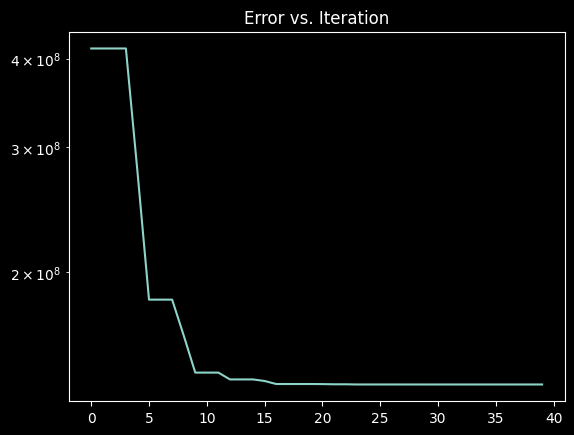

In [10]:
#Print out the resulting parameter values

parameters = ['Rho', 'Xi', 'Kappa', 'Theta', 'v0']
for param, value in zip(parameters, param_vector):
    print(f"{param:<5} is {value:>7.4f}")

#Plot error vs. iteration
plt.plot(error_list)
plt.yscale('log')
plt.title('Error vs. Iteration')
plt.show()

In [11]:
#Check analytical derivative against numberical derivative

max_row = len(options_data)
rand_rows = random.sample(range(0, max_row), 30)
h = 1e-6

error_mat = []
for j, idx in enumerate(rand_rows):
    row = list(options_data.iloc[idx])
    error_list = []
    for i in range(5):
        p_up = param_vector.copy()
        p_dn = param_vector.copy()
        p_up[i] += h
        p_dn[i] -= h

        price_up = heston_price_optimized(current_price, row[0], rfr, row[1], *p_up, row[3])
        price_dn = heston_price_optimized(current_price, row[0], rfr, row[1], *p_dn, row[3])
        fd = (price_up - price_dn) / (2*h)

        vega = options_data.iloc[idx]['Vega']
        analytical = list(jacobian.iloc[idx])[i] * vega
        relative_error = (np.abs(analytical - fd) / np.maximum(1e-8, np.abs(fd)))[0]
        error_list.append(relative_error)
    error_mat.append(error_list)

***

#### *Below is an algorithm originally to be used, but was decided against*

Differential Evolution is a stochastic, population-based algorithm that doesn't need any gradient information; it only evaluates the actual function.  
Assume a loss function $f(\bm{\theta})$, where the parameter vector $\bm{\theta}$ is $D$-dimensional, then 4 separate steps are taken for each *Generation*: Initialization, Mutation, Crossover, and Selection.
1. <u>Initialization</u>  
    First, a population of $N$ vectors from the search space is randomly selected for generation $G$:
    $$Population = \{\bm{\theta}_1^{\{G\}}, \bm{\theta}_2^{\{G\}}, \dots, \bm{\theta}_N^{\{G\}} \}$$
    The search space is defined by a lower and upper bound for each dimension:
    - Let $\theta_{min, j}$ be the lower bound for dimension $j$
    - Let $\theta_{max, j}$ be the upper bound for dimension $j$
    Then, the $j-th$ component of the $i-th$ vector is selected as (again for generation $G$):
    $$\theta_{j, i}^{\{G\}} = \theta_{min, j} + \textrm{rand}(0, 1) \cdot (\theta_{max, j} - \theta_{min, j})$$
    Where the $i-th$ vector will then be:
    $$\bm{\theta}_i^{\{G\}} = \langle \theta_{0, i}^{\{G\}}, \theta_{1, i}^{\{G\}}, \dots, \theta_{j, i}^{\{G\}}, \dots, \theta_{D, i}^{\{G\}}\rangle$$
    *$N$ is a hyperparameter usually in the range $[5D, 10D]$.*

2. <u>Mutuation</u>  
    For every vector $\bm{\theta}_I^{\{G\}}$ in $Population$, a "mutant vector" is created, $\mathbf{m}_i^{\{G+1\}}$.    
    To start, three distint vectors, $\{\bm{\theta}_a^{\{G\}}, \bm{\theta}_b^{\{G\}}, \bm{\theta}_c^{\{G\}}\}$, from $Population$ are selected, such that $a, b, c \neq i$.  
    Then, the mutant vector is created as follows:
    $$\mathbf{m}_i^{\{G+1\}} = \bm{\theta}_a^{\{G\}} + F\cdot \left(\bm{\theta}_b^{\{G\}} - \bm{\theta}_c^{\{G\}}\right)$$
    where $F$ is the *mutuation factor*.  
    Essentially, $\bm{\theta}_b^{\{G\}} - \bm{\theta}_c^{\{G\}}$ is a random direction in the parameter space (scaled by $F$), and this direction is added to $\bm{\theta}_a^{\{G\}}$ to create a random point in the parameter space.  
    *$F$ is a hyperparameter strictly in the range $(0, 2]$.*

3. <u>Crossover</u>  
    Simply mutating the vectors into the mutant vector can result in losing too many good traits, thus some traits are retained and some other are crossed over into a new "trial vector:" $\mathbf{u}_i^{G+1}$.  
    For each dimension $j \in [1, D]$, the components of the trial vector are created as follows:
    $$u_{j, i}^{\{G+1\}} = 
    \begin{cases}
    m_{j, i}^{\{G+1\}} & \quad if ~ \textrm{rand}(0, 1) \leq CR ~ or ~ j = j_{rand} \\
    \theta_{j, i}^{\{G\}} & \quad otherwise \\
    \end{cases}$$
    Essentially, for each component of the trial vector, the mutant component is selected if a random number is less than the crossover rate $CR$ (the larger the crossover rate, the more mutuation will occur, and vice versa). However, it is possible that, by random chance, *no* dimensions accept the mutation, therefore a random dimension, $j_{rand}$ is chosen which will automatically accept the mutuation so that the trial vector differs from the original vector by at least one component.  
    *$CR$ is a hyperparameter usually in the range $[0.1, 0.9]$.*

4. <u>Selection</u>  
    Finally, the trial vector is compared to the original vector and whichever yields a lower function value will replace the original vector for the next generation:
    $$\bm{\theta}_i^{\{G+1\}} = 
    \begin{cases}
    \mathbf{u}_i^{\{G+1\}} & \quad if ~ f(\mathbf{u}_i^{\{G+1\}}) \leq f(\bm{\theta}_i^{\{G\}}) \\
    \bm{\theta}_i^{\{G\}} & \quad otherwise
    \end{cases}$$
    This ensures that the population never regresses, and that each subsequent generation has a lower or equal overall function value.

    **With these two algorithms, the final optimization workflow can be formalized:**    
    - First, the global optimizer, *Differential Evolution*, will be initialized and run.
        - The DE algorithm will be allowed to continue running until the *best loss function value* stops improving (within a tolerance, $\epsilon$):  
        If the best loss function value at the $k-th$ generation is $L_{min}^{\{k\}}$, then the algorithm is stopped once:
        $$\big| L_{min}^{\{k\}} - L_{min}^{\{k - 10\}} \big| < \epsilon$$
        - Once this value stops changing, it means that DE can no longer make meaningful progress, and a local optimizer should now be used.
    - The best parameter vector from the $Population$ that created the best loss function value is extracted and used as the starting point for the Levenberg–Marquardt algorithm.
        - Now, fast local convergence can occur.
        - Once the LM algorithm stops improving, within a tolerance, the parameters that it stops on are the *final parameters*.

***

Original paper by Steven Heston from the Imperial College London archive:
https://www.ma.imperial.ac.uk/~ajacquie/IC_Num_Methods/IC_Num_Methods_Docs/Literature/Heston.pdf  

Original paper by Cui et. al. from *arXiv*:  
https://arxiv.org/abs/1511.08718